Gioele Checchi, Daniel Badaire, Yiming Xu, Manuel Griseri

# Rough and lifted Bergomi models for SPX and VIX option pricing

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq, differential_evolution
from scipy.special import gamma as gamma_func
from scipy.interpolate import interp1d

## 1. Data

In [ ]:
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/graphs_vol'
os.makedirs(save_path, exist_ok=True)

Mounted at /content/drive


In [ ]:
# 3 months US treasury bill rate: we will use it after as risk free rate in BS for instance
irx = yf.download("^IRX", start="2026-03-01", end="2026-03-17", auto_adjust=False)
r_val = float(irx["Close"].dropna().iloc[-1].item() / 100)
print("\n",r_val)

[*********************100%***********************]  1 of 1 completed


 0.036050000190734864


### 1.1. SPX implied vol surface

In [ ]:
# Folder in Google Drive containing the CSV files
folder = "/content/drive/MyDrive/Vol"

# Reference date: today = March 16, 2026
today = pd.Timestamp("2026-03-16")

# Spot used for log-moneyness
S0 = 6706.2202

# File -> target expiration mapping
target_expiries = {
    "March26.csv":   "Mon Mar 23 2026",
    "April.csv":     "Thu Apr 16 2026",
    "May.csv":       "Fri May 29 2026",
    "June.csv":      "Tue Jun 30 2026",
    "July.csv":      "Fri Jul 31 2026",
    "August.csv":    "Mon Aug 31 2026",
    "September.csv": "Wed Sep 30 2026",
    "December.csv":  "Thu Dec 31 2026",
}

# Helper function
def year_fraction(expiry_str, ref_date=today):
    """
    Convert an expiration string like 'Thu Apr 16 2026'
    into a year fraction using ACT/365 from ref_date.
    """
    expiry_date = pd.to_datetime(expiry_str)
    return (expiry_date - ref_date).days / 365.0

In [ ]:
# Main extraction loop
all_tables = []

for file_name, target_expiry in target_expiries.items():
    file_path = os.path.join(folder, file_name)

    # Read the CSV:
    # row 4 contains the column names, so we skip the first 3 rows
    df = pd.read_csv(file_path, skiprows=3)

    # Keep only the rows for the required expiration
    sub = df[df["Expiration Date"] == target_expiry].copy()

    # Keep the rows in the same order as they appear in the file
    sub = sub.reset_index(drop=True)

    # Build a new table:
    # - first half of the rows: use put IV from column 'IV.1'
    # - last half: use call IV from column 'IV'
    # We do this, for the low liquidity of ITM options
    T = year_fraction(target_expiry)

    rows = []

    for i in range(len(sub)):
        strike = float(sub.loc[i, "Strike"])

        if strike < S0:
            implied_vol = float(sub.loc[i, "IV.1"])   # put IV
            option_side = "put"
        else:
            implied_vol = float(sub.loc[i, "IV"])     # call IV
            option_side = "call"

        rows.append({
            "expiration": T,
            "strike": strike,
            "implied_vol": implied_vol,
            "expiration_label": target_expiry,
            "option_side": option_side
        })

    out = pd.DataFrame(rows)
    all_tables.append(out)

# Concatenate all maturities into one final table
final_table = pd.concat(all_tables, ignore_index=True)

# Sort by maturity and strike
final_table = final_table.sort_values(["expiration", "strike"]).reset_index(drop=True)

# Print the final table
print("Final table:")
print(final_table)

Final table:
      expiration  strike  implied_vol expiration_label option_side
0       0.019178  2800.0       1.6950  Mon Mar 23 2026         put
1       0.019178  3000.0       1.5656  Mon Mar 23 2026         put
2       0.019178  3200.0       1.4445  Mon Mar 23 2026         put
3       0.019178  3400.0       1.3306  Mon Mar 23 2026         put
4       0.019178  3600.0       1.2231  Mon Mar 23 2026         put
...          ...     ...          ...              ...         ...
2259    0.794521  8300.0       0.1338  Thu Dec 31 2026        call
2260    0.794521  8400.0       0.1333  Thu Dec 31 2026        call
2261    0.794521  8500.0       0.1332  Thu Dec 31 2026        call
2262    0.794521  8600.0       0.1334  Thu Dec 31 2026        call
2263    0.794521  8800.0       0.1346  Thu Dec 31 2026        call

[2264 rows x 5 columns]


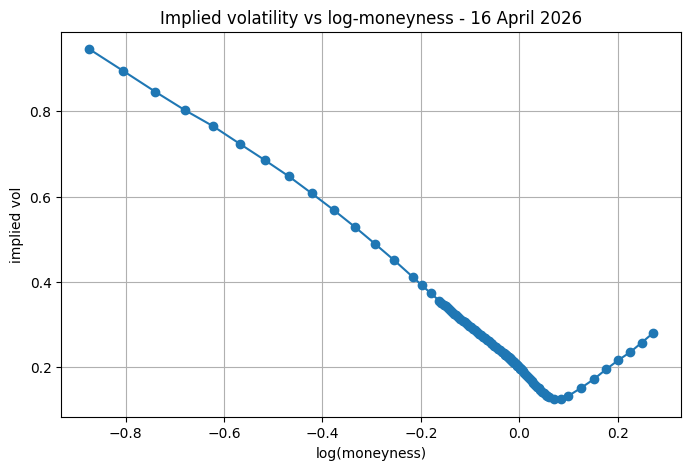

In [ ]:
# Add log-moneyness column
final_table["log_moneyness"] = np.log(final_table["strike"] / S0)

# Plot 1: IV vs log-moneyness for April 16, 2026
april_label = "Thu Apr 16 2026"
april_data = final_table[final_table["expiration_label"] == april_label].copy()

plt.figure(figsize=(8, 5))
plt.plot(april_data["log_moneyness"], april_data["implied_vol"], marker="o")
plt.xlabel("log(moneyness)")
plt.ylabel("implied vol")
plt.title("Implied volatility vs log-moneyness - 16 April 2026")
plt.grid(True)
plt.savefig(os.path.join(save_path, 'volK.png'))
plt.show()


Rows with K = 6700:
      expiration  strike  implied_vol expiration_label option_side  \
120     0.019178  6700.0       0.2124  Mon Mar 23 2026         put   
282     0.084932  6700.0       0.2002  Thu Apr 16 2026         put   
536     0.202740  6700.0       0.1954  Fri May 29 2026         put   
963     0.290411  6700.0       0.1941  Tue Jun 30 2026         put   
1217    0.375342  6700.0       0.1966  Fri Jul 31 2026         put   
1407    0.460274  6700.0       0.1973  Mon Aug 31 2026         put   
1638    0.542466  6700.0       0.1988  Wed Sep 30 2026         put   
2005    0.794521  6700.0       0.2022  Thu Dec 31 2026         put   

      log_moneyness  
120       -0.000928  
282       -0.000928  
536       -0.000928  
963       -0.000928  
1217      -0.000928  
1407      -0.000928  
1638      -0.000928  
2005      -0.000928  


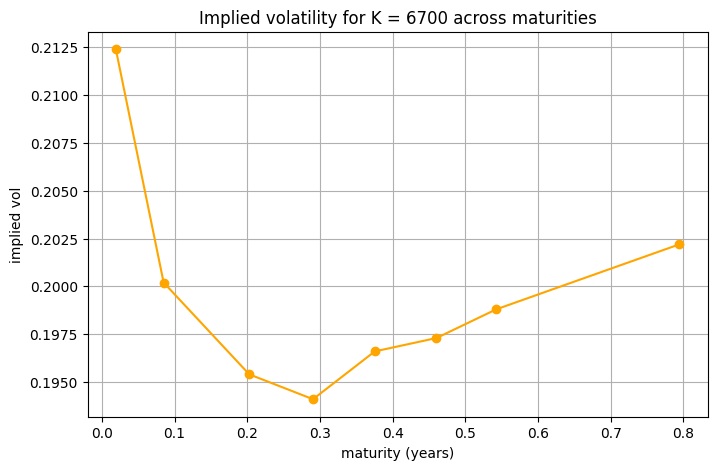

In [ ]:
# Plot 2: IV for K = 6700 across all maturities
k_target = 6700.0
k_data = final_table[np.isclose(final_table["strike"], k_target)].copy()
k_data = k_data.sort_values("expiration")

print("\nRows with K = 6700:")
print(k_data)

plt.figure(figsize=(8, 5))
plt.plot(k_data["expiration"], k_data["implied_vol"], marker="o", color="orange")
plt.xlabel("maturity (years)")
plt.ylabel("implied vol")
plt.title("Implied volatility for K = 6700 across maturities")
plt.grid(True)
plt.savefig(os.path.join(save_path, 'volT.png'))
plt.show()

### 1.2. VIX implied vol surface

In [ ]:
# File -> (target expiration, VIX future) mapping
vix_targets = {
    "AprilV.csv":     ("Wed Apr 15 2026", 23.32),
    "MayV.csv":       ("Tue May 19 2026", 23.05),
    "JuneV.csv":      ("Wed Jun 17 2026", 23.00),
    "JulyV.csv":      ("Wed Jul 22 2026", 23.32),
    "AugustV.csv":    ("Wed Aug 19 2026", 23.35),
    "SeptemberV.csv": ("Wed Sep 16 2026", 23.57),
    "OctoberV.csv":   ("Wed Oct 21 2026", 23.70),
    "NovemberV.csv":  ("Wed Nov 18 2026", 23.62),
}

In [ ]:
# Main extraction loop for VIX
all_vix_tables = []

for file_name, (target_expiry, fut) in vix_targets.items():
    file_path = os.path.join(folder, file_name)

    # Row 4 contains the column names, so skip the first 3 rows
    df = pd.read_csv(file_path, skiprows=3)

    # Keep only the rows for the required expiration
    sub = df[df["Expiration Date"] == target_expiry].copy()

    # Keep the original order
    sub = sub.reset_index(drop=True)

    T = year_fraction(target_expiry)

    rows = []

    for i in range(len(sub)):
        strike = float(sub.loc[i, "Strike"])

        # Use put IV for strikes below the VIX future,
        # and call IV for strikes at/above the VIX future
        if strike < fut:
            implied_vol = float(sub.loc[i, "IV.1"])   # put IV
            option_side = "put"
        else:
            implied_vol = float(sub.loc[i, "IV"])     # call IV
            option_side = "call"

        rows.append({
            "expiration": T,
            "strike": strike,
            "implied_vol": implied_vol,
            "expiration_label": target_expiry,
            "future": fut,
            "log_moneyness": np.log(strike / fut),
            "option_side": option_side
        })

    out = pd.DataFrame(rows)
    all_vix_tables.append(out)

# Concatenate all maturities into one final VIX table
vix_table = pd.concat(all_vix_tables, ignore_index=True)

# Sort by maturity and strike
vix_table = vix_table.sort_values(["expiration", "strike"]).reset_index(drop=True)

# Print the final table
print("Final VIX table:")
print(vix_table)

Final VIX table:
     expiration  strike  implied_vol expiration_label  future  log_moneyness  \
0      0.082192    10.0       1.1887  Wed Apr 15 2026   23.32      -0.846726   
1      0.082192    10.5       1.1246  Wed Apr 15 2026   23.32      -0.797936   
2      0.082192    11.0       1.0636  Wed Apr 15 2026   23.32      -0.751416   
3      0.082192    11.5       1.0052  Wed Apr 15 2026   23.32      -0.706964   
4      0.082192    12.0       0.9492  Wed Apr 15 2026   23.32      -0.664405   
..          ...     ...          ...              ...     ...            ...   
485    0.676712   160.0       1.0148  Wed Nov 18 2026   23.62       1.913080   
486    0.676712   170.0       1.0228  Wed Nov 18 2026   23.62       1.973705   
487    0.676712   180.0       1.0365  Wed Nov 18 2026   23.62       2.030863   
488    0.676712   190.0       1.0433  Wed Nov 18 2026   23.62       2.084930   
489    0.676712   200.0       1.0580  Wed Nov 18 2026   23.62       2.136224   

    option_side  
0   

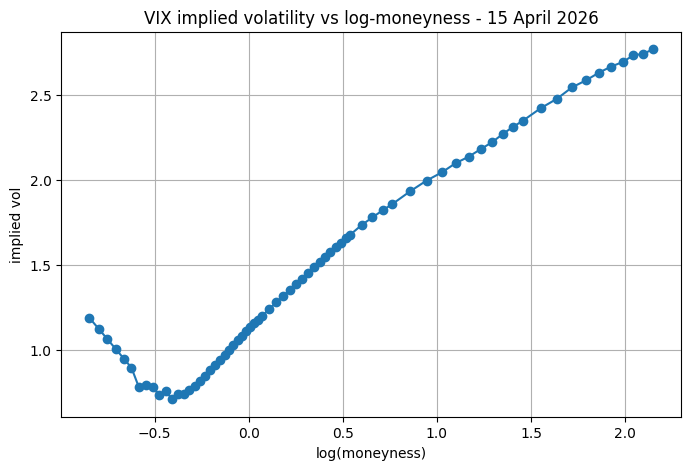

In [ ]:
# Plot 1: IV vs log-moneyness for April VIX options
april_label_vix = "Wed Apr 15 2026"
april_vix = vix_table[vix_table["expiration_label"] == april_label_vix].copy()

plt.figure(figsize=(8, 5))
plt.plot(april_vix["log_moneyness"], april_vix["implied_vol"], marker="o")
plt.xlabel("log(moneyness)")
plt.ylabel("implied vol")
plt.title("VIX implied volatility vs log-moneyness - 15 April 2026")
plt.grid(True)
plt.savefig(os.path.join(save_path, 'volK vix.png'))
plt.show()


Rows with K = 20:
     expiration  strike  implied_vol expiration_label  future  log_moneyness  \
20     0.082192    20.0       0.9407  Wed Apr 15 2026   23.32      -0.153579   
85     0.175342    20.0       0.8122  Tue May 19 2026   23.05      -0.141933   
145    0.254795    20.0       0.7289  Wed Jun 17 2026   23.00      -0.139762   
205    0.350685    20.0       0.6506  Wed Jul 22 2026   23.32      -0.153579   
265    0.427397    20.0       0.6005  Wed Aug 19 2026   23.35      -0.154865   
325    0.504110    20.0       0.5632  Wed Sep 16 2026   23.57      -0.164242   
385    0.600000    20.0       0.5318  Wed Oct 21 2026   23.70      -0.169743   
445    0.676712    20.0       0.5329  Wed Nov 18 2026   23.62      -0.166362   

    option_side  
20          put  
85          put  
145         put  
205         put  
265         put  
325         put  
385         put  
445         put  


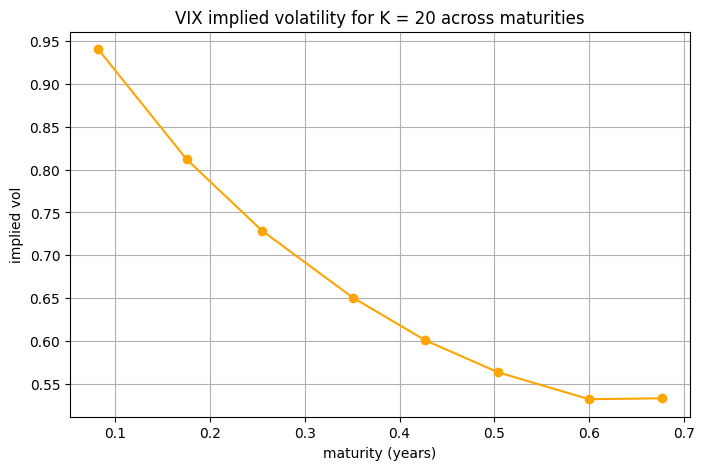

In [ ]:
# Plot 2: IV for K = 20 across all maturities
k_target = 20.0
k20_data = vix_table[np.isclose(vix_table["strike"], k_target)].copy()
k20_data = k20_data.sort_values("expiration")

print("\nRows with K = 20:")
print(k20_data)

plt.figure(figsize=(8, 5))
plt.plot(k20_data["expiration"], k20_data["implied_vol"], marker="o", color="orange")
plt.xlabel("maturity (years)")
plt.ylabel("implied vol")
plt.title("VIX implied volatility for K = 20 across maturities")
plt.grid(True)
plt.savefig(os.path.join(save_path, 'volT vix.png'))
plt.show()


Futures vs maturities:
   expiration  future expiration_label
0    0.082192   23.32  Wed Apr 15 2026
1    0.175342   23.05  Tue May 19 2026
2    0.254795   23.00  Wed Jun 17 2026
3    0.350685   23.32  Wed Jul 22 2026
4    0.427397   23.35  Wed Aug 19 2026
5    0.504110   23.57  Wed Sep 16 2026
6    0.600000   23.70  Wed Oct 21 2026
7    0.676712   23.62  Wed Nov 18 2026


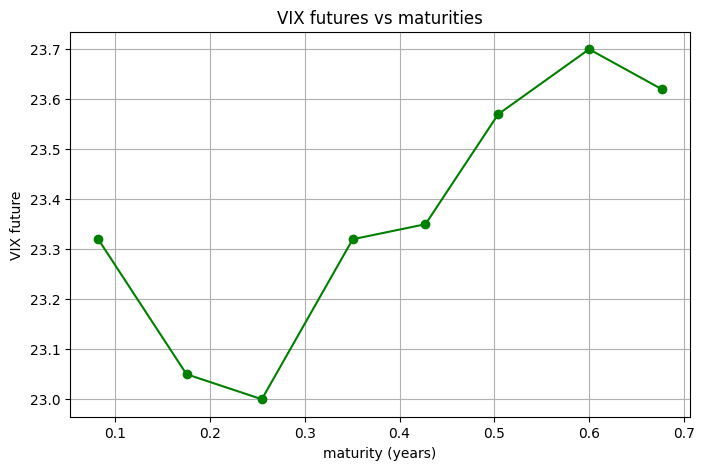

In [ ]:
# Plot 3: VIX futures vs maturities
futures_curve = (
    vix_table[["expiration", "future", "expiration_label"]]
    .drop_duplicates()
    .sort_values("expiration")
    .reset_index(drop=True)
)

print("\nFutures vs maturities:")
print(futures_curve)

plt.figure(figsize=(8, 5))
plt.plot(futures_curve["expiration"], futures_curve["future"], marker="o", color="green")
plt.xlabel("maturity (years)")
plt.ylabel("VIX future")
plt.title("VIX futures vs maturities")
plt.grid(True)
plt.savefig(os.path.join(save_path, 'futures.png'))
plt.show()

## 2. Bergomi models

### 2.1. Pricing engines

In [ ]:
# Black-Scholes and Black76 utilities
def bs_call_price(S, K, T, r, sigma):
    """European call price under Black-Scholes."""
    if T <= 1e-12 or sigma <= 1e-12:
        return max(S - K * np.exp(-r * T), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_iv(price, S, K, T, r):
    """Invert BS call formula to recover implied volatility."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    try:
        return brentq(lambda sig: bs_call_price(S, K, T, r, sig) - price,
                      1e-4, 10.0)
    except Exception:
        return np.nan

def black76_call(F, K, T, r, sigma):
    """Black-76 call price on a forward."""
    if T <= 1e-12 or sigma <= 1e-12:
        return np.exp(-r * T) * max(F - K, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def black76_iv(price, F, K, T, r):
    """Invert Black-76 call formula for implied volatility."""
    intrinsic = np.exp(-r * T) * max(F - K, 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    try:
        return brentq(lambda sig: black76_call(F, K, T, r, sig) - price,
                      1e-4, 10.0)
    except Exception:
        return np.nan

In [ ]:
# Build xi_0(T) as piecewise-constant derivative of total variance
# Extract ATM total variance nodes from market data
T_atm = []
w_atm = []
for T_val in sorted(final_table['expiration'].unique()):
    sub = final_table[final_table['expiration'] == T_val]
    idx = (sub['strike'] - S0).abs().idxmin()
    sigma = sub.loc[idx, 'implied_vol']
    T_atm.append(T_val)
    w_atm.append(T_val * sigma ** 2)   # w(T) = T * sigma_ATM^2

T_atm = np.array([0.0] + T_atm)   # Anchor w(0) = 0
w_atm = np.array([0.0] + w_atm)

# Forward variance curve
# Build xi_0(T) as piecewise-constant derivative of total variance
def xi0_func(T):
    """Forward variance xi_0(T) = dw/dT, piecewise constant."""
    T = np.asarray(T, dtype=float)
    out = np.zeros_like(T)
    for j, t in enumerate(T.flat):
        if t <= T_atm[1]:
            out.flat[j] = w_atm[1] / T_atm[1]
        elif t >= T_atm[-1]:
            out.flat[j] = (w_atm[-1] - w_atm[-2]) / (T_atm[-1] - T_atm[-2])
        else:
            i = np.searchsorted(T_atm, t) - 1
            out.flat[j] = (w_atm[i + 1] - w_atm[i]) / (T_atm[i + 1] - T_atm[i])
    return float(out) if out.ndim == 0 else out

# Kernel approximation (geometric partition)
def kernel_params(H, n_factors, r_geom):
    """
    Weights c_i and mean-reversion speeds x_i approximating the
    fractional kernel t^{alpha-1}/Gamma(alpha) with alpha = H + 1/2.
    """
    alpha = H + 0.5
    i_arr = np.arange(1, n_factors + 1, dtype=float)
    c = ((r_geom ** (1 - alpha) - 1)
         / (gamma_func(alpha) * gamma_func(2 - alpha))
         * r_geom ** ((1 - alpha) * (i_arr - 1 - n_factors / 2)))
    x = ((1 - alpha) / (2 - alpha)
         * (r_geom ** (2 - alpha) - 1) / (r_geom ** (1 - alpha) - 1)
         * r_geom ** (i_arr - 1 - n_factors / 2))
    return c, x

In [ ]:
# MC helpers (shared by both models)
def mc_spx_calls(log_S, t_grid, r, strikes, T):
    """MC call prices at maturity T from simulated log-price paths."""
    k = np.argmin(np.abs(t_grid - T))
    S_T = np.exp(log_S[:, k])
    df = np.exp(-r * t_grid[k])
    return np.array([df * np.mean(np.maximum(S_T - K, 0)) for K in strikes])

def mc_vix_ivs(vix_samples, vix_future, r, T, strikes):
    """MC VIX call prices -> Black-76 implied vols.
    Additive shift to match the market future."""
    shift = vix_future - np.mean(vix_samples)
    vix_shifted = vix_samples + shift
    ivs = np.full(len(strikes), np.nan)
    df = np.exp(-r * T)
    for i, K in enumerate(strikes):
        price = df * np.mean(np.maximum(vix_shifted - K, 0))
        ivs[i] = black76_iv(price, vix_future, K, T, r)
    return ivs

def spx_model_ivs(pricer, data, S0, r):
    """Compute BS implied vols for every row in an SPX dataframe."""
    ivs = np.full(len(data), np.nan)
    for T in data['expiration'].unique():
        mask = data['expiration'] == T
        sub = data.loc[mask]
        cp = pricer(sub['strike'].values, T)
        for j, (idx, row) in enumerate(sub.iterrows()):
            ivs[data.index.get_loc(idx)] = bs_iv(cp[j], S0, row['strike'], T, r)
    return ivs

### 2.2. Rough Bergomi

In [ ]:
def rbergomi_simulate(H, eta, rho, xi0_func, S0, r, T_max, N_steps, N_paths, seed=42):
    """Simulate rBergomi on [0, T_max]."""
    rng = np.random.RandomState(seed)
    dt = T_max / N_steps
    t_grid = np.arange(N_steps + 1) * dt
    a = eta * np.sqrt(2 * H)

    Z1, Z2 = rng.randn(N_paths, N_steps), rng.randn(N_paths, N_steps)
    dW = Z1 * np.sqrt(dt)
    dB = rho * dW + np.sqrt(1 - rho**2) * Z2 * np.sqrt(dt)

    # Point-evaluation kernel weights
    w = (np.arange(1, N_steps + 1) * dt) ** (H - 0.5)   # Adjusted to be consistent with the vix funct

    # FFT convolution
    n_fft = 1
    while n_fft < 2 * N_steps:
        n_fft *= 2
    conv = np.fft.irfft(
        np.fft.rfft(w, n=n_fft)[np.newaxis, :] *
        np.fft.rfft(dW, n=n_fft, axis=1),
        n=n_fft, axis=1)[:, :N_steps]

    W_tilde = np.zeros((N_paths, N_steps + 1))
    W_tilde[:, 1:] = conv

    # Discrete drift: use actual variance of w-convolution
    # Var(W_tilde[k]) = dt * sum_{j=0}^{k-1} w[j]^2
    cumvar = np.zeros(N_steps + 1)
    cumvar[1:] = np.cumsum(w ** 2) * dt
    drift = -0.5 * a ** 2 * cumvar

    # Variance and forward variance
    xi0_arr = np.array([xi0_func(t) for t in t_grid])
    V = xi0_arr[np.newaxis, :] * np.exp(a * W_tilde + drift[np.newaxis, :])

    # Log-price (Euler)
    log_S = np.full((N_paths, N_steps + 1), np.log(S0))
    for k in range(N_steps):
        Vk = np.maximum(V[:, k], 0.0)
        log_S[:, k + 1] = (log_S[:, k] + (r - 0.5 * Vk) * dt
                           + np.sqrt(Vk) * dB[:, k])
    return log_S, V, t_grid, dW

def rbergomi_vix(H, eta, xi0_func, dW, dt, T_vix, Delta=30 / 365, M=15):
    """
    Compute VIX_T (in percentage points) for each MC path.
    Uses the conditional-expectation formula for E[V_s | F_T].
    """
    N_paths, N_steps = dW.shape
    k_T = min(int(round(T_vix / dt)), N_steps)
    if k_T < 1:
        v0 = xi0_func(T_vix)
        # Use the same time grid as in the simulation to avoid discretization mismatch
        return 100 * np.sqrt(max(v0, 0.0)) * np.ones(N_paths)
    a = eta * np.sqrt(2 * H)
    s_arr = np.linspace(T_vix, T_vix + Delta, M + 1)
    t_grid = np.arange(N_steps + 1) * dt
    t_j = t_grid[:k_T]

    # Build weight matrix: W_mat[j, m] = (s_m - t_j)^{H-0.5}
    eps = 1e-10
    # Safety addition as s could be close to t_j
    W_mat = np.maximum(s_arr[np.newaxis, :] - t_j[:, np.newaxis], eps) ** (H - 0.5)
    cond_means = dW[:, :k_T] @ W_mat   # (N_paths, M+1)

    # Trapezoidal integration of E[V_s | F_T]
    avg_V = np.zeros(N_paths)

    # Precompute discrete variance of the Volterra process using same kernel as simulation
    ell = np.arange(1, k_T + 1)
    w = (ell * dt) ** (H - 0.5)
    cumvar_T = np.sum(w ** 2) * dt

    for m, s in enumerate(s_arr):
      # Discrete approximation of Var(W_s^H - W_T^H)
      tau = s - T_vix
      k_tau = int(round(tau / dt))

      if k_tau > 0:
          ell_tau = np.arange(1, k_tau + 1)
          w_tau = (ell_tau * dt) ** (H - 0.5)
          var_increment = np.sum(w_tau ** 2) * dt
      else:
          var_increment = 0.0

      correction = var_increment
      # Total variance up to s
      k_s = int(round(s / dt))
      ell_s = np.arange(1, k_s + 1)
      w_s = (ell_s * dt) ** (H - 0.5)
      var_total = np.sum(w_s ** 2) * dt

      # We rewrite the conditional expectation in full lognormal form:
      # E[V_s | F_T] = xi0(s) * exp(
      #     a * E[Y_s | F_T]
      #     + 0.5 a^2 Var(Y_s | F_T)
      #     - 0.5 a^2 Var(Y_s)
      # )
      # This matches the lifted Bergomi formulation and ensures
      # consistency of the lognormal structure of volatility.
      E_Vs = xi0_func(s) * np.exp(a * cond_means[:, m] + 0.5 * a**2 * (var_increment - var_total))
      trap_w = 0.5 if (m == 0 or m == M) else 1.0
      avg_V += trap_w * E_Vs

    avg_V /= M   # Trapezoidal average
    return 100 * np.sqrt(np.maximum(avg_V, 0.0))

### 2.3. Lifted Bergomi

In [ ]:
def lbergomi_simulate(c, x, eta, H, rho, xi0_func, S0, r, T_max,
                      N_steps, N_paths, snapshot_times=None, seed=42):
    """Simulate Lifted Bergomi."""
    rng = np.random.RandomState(seed)
    n = len(c)
    dt = T_max / N_steps
    a = eta * np.sqrt(2 * H)

    snap_idx = {}
    if snapshot_times is not None:
        for ts in snapshot_times:
            snap_idx[int(round(ts / dt))] = ts

    Z1, Z2 = rng.randn(N_paths, N_steps), rng.randn(N_paths, N_steps)
    dW = Z1 * np.sqrt(dt)
    dB = rho * dW + np.sqrt(1 - rho**2) * Z2 * np.sqrt(dt)

    # Implicit Euler decay factors
    decay = 1.0 / (1.0 + x * dt)   # (n,)

    # Discrete variance of Y_k = sum_i c_i U^i_k
    # U^i_k = sum_{j<k} d_i^{k-j} dW_j  =>  alpha_l = sum_i c_i d_i^l
    # Var(Y_k) = dt * sum_{l=1}^{k} alpha_l^2
    l_arr = np.arange(0, N_steps, dtype=float)
    d_powers = decay[np.newaxis, :] ** l_arr[:, np.newaxis]   # Now starts at l=0
    alphas = d_powers @ c
    varY_arr = np.zeros(N_steps + 1)
    varY_arr[1:] = np.cumsum(alphas ** 2) * dt

    U = np.zeros((N_paths, n))
    log_S = np.full((N_paths, N_steps + 1), np.log(S0))
    V = np.zeros((N_paths, N_steps + 1))
    V[:, 0] = xi0_func(0.0)
    snapshots = {}

    for k in range(N_steps):
        U = U * decay[np.newaxis, :] + dW[:, k:k+1]
        Y = U @ c
        V[:, k + 1] = xi0_func((k + 1) * dt) * np.exp(
            a * Y - 0.5 * a ** 2 * varY_arr[k + 1])
        Vk = np.maximum(V[:, k], 0.0)
        log_S[:, k + 1] = (log_S[:, k] + (r - 0.5 * Vk) * dt
                           + np.sqrt(Vk) * dB[:, k])
        if k + 1 in snap_idx:
            snapshots[snap_idx[k + 1]] = U.copy()

    return log_S, V, np.arange(N_steps + 1) * dt, snapshots

def lbergomi_vix(c, x, eta, H, xi0_func, U_T, T_vix,
                 Delta=30 / 365, M=15):
    """
    Compute VIX_T (percent) from Lifted Bergomi factor snapshot at T.
    Uses the log-normal conditional expectation E[V_s | F_T].
    """
    n = len(c)
    a = eta * np.sqrt(2 * H)
    xsum = x[:, None] + x[None, :]
    cprod = c[:, None] * c[None, :]

    s_arr = np.linspace(T_vix, T_vix + Delta, M + 1)
    N_paths = U_T.shape[0]
    avg_V = np.zeros(N_paths)

    for m, s in enumerate(s_arr):
        tau = s - T_vix
        # Conditional mean: sum_i c_i e^{-x_i tau} U_T^(i)
        decay = np.exp(-x * tau)
        mu_cond = (c[np.newaxis, :] * decay[np.newaxis, :] * U_T).sum(axis=1)
        # Conditional variance of Y_s given F_T
        var_cond = np.sum(cprod * (1 - np.exp(-xsum * tau)) / xsum)
        # Total variance of Y_s
        var_total = np.sum(cprod * (1 - np.exp(-xsum * s)) / xsum)
        E_Vs = xi0_func(s) * np.exp(
            a * mu_cond + 0.5 * a**2 * var_cond - 0.5 * a**2 * var_total)
        trap_w = 0.5 if (m == 0 or m == M) else 1.0
        avg_V += trap_w * E_Vs
    avg_V /= M
    return 100 * np.sqrt(np.maximum(avg_V, 0.0))

## 3. Calibration

In [ ]:
# Filter data
LM_SPX = (-0.15, 0.10)
N_STRIKES_PER_MAT = 20

# Filter out zero-volume strikes from both sides
spx_filtered = final_table[
    (final_table['log_moneyness'] >= LM_SPX[0]) &
    (final_table['log_moneyness'] <= LM_SPX[1])
].copy()

spx_cal_list = []
for T_val in spx_filtered['expiration'].unique():
    sub = spx_filtered[spx_filtered['expiration'] == T_val].sort_values('strike')
    if len(sub) <= N_STRIKES_PER_MAT:
        spx_cal_list.append(sub)
    else:
        idx = np.round(np.linspace(0, len(sub) - 1, N_STRIKES_PER_MAT)).astype(int)
        spx_cal_list.append(sub.iloc[idx])
spx_cal = pd.concat(spx_cal_list, ignore_index=True)

LM_VIX = (-0.40, 0.30)
N_STRIKES_PER_MAT_VIX = 20

vix_filtered = vix_table[
    (vix_table['log_moneyness'] >= LM_VIX[0]) &
    (vix_table['log_moneyness'] <= LM_VIX[1])
].copy()

vix_cal_list = []
for T_val in vix_filtered['expiration'].unique():
    sub = vix_filtered[vix_filtered['expiration'] == T_val].sort_values('strike')
    if len(sub) <= N_STRIKES_PER_MAT_VIX:
        vix_cal_list.append(sub)
    else:
        idx = np.round(np.linspace(0, len(sub) - 1, N_STRIKES_PER_MAT_VIX)).astype(int)
        vix_cal_list.append(sub.iloc[idx])
vix_cal = pd.concat(vix_cal_list, ignore_index=True)

DELTA_VIX = 30 / 365
N_PATHS_CAL = 500
N_STEPS_PER_YEAR = 100
T_MAX = max(spx_cal['expiration'].max(),
            vix_cal['expiration'].max() + DELTA_VIX) + 0.02
VIX_MATS = sorted(vix_cal['expiration'].unique())

print(f"SPX calibration set: {len(spx_cal)} options, "
      f"{spx_cal['expiration'].nunique()} maturities")
print(f"VIX calibration set: {len(vix_cal)} options, "
      f"{vix_cal['expiration'].nunique()} maturities")

SPX calibration set: 160 options, 8 maturities
VIX calibration set: 132 options, 8 maturities


Estimated H from ATM skew: H ≈ 0.0610


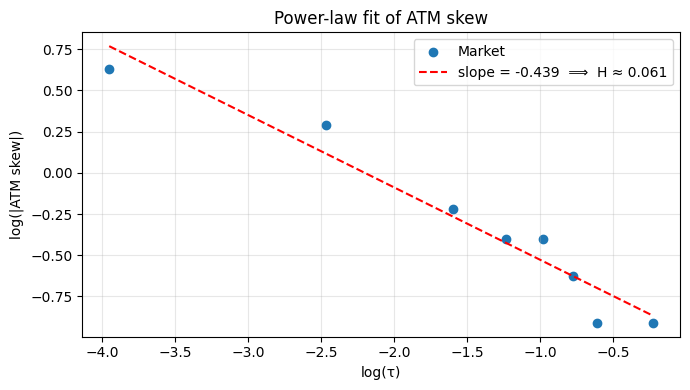

In [ ]:
# Estimate H from ATM skew
spx_mats = sorted(final_table['expiration'].unique())
atm_skews = []
for T_val in spx_mats:
    sub = final_table[final_table['expiration'] == T_val].sort_values('strike')
    below = sub[sub['strike'] <= S0].iloc[-1]
    above = sub[sub['strike'] > S0].iloc[0]
    dk = np.log(above['strike'] / S0) - np.log(below['strike'] / S0)
    atm_skews.append(-(above['implied_vol'] - below['implied_vol']) / dk)

log_tau = np.log(np.array(spx_mats))
log_skew = np.log(np.array(atm_skews))
slope, intercept = np.polyfit(log_tau, log_skew, 1)
H_est = slope + 0.5
print(f"Estimated H from ATM skew: H ≈ {H_est:.4f}")

plt.figure(figsize=(7, 4))
plt.scatter(log_tau, log_skew, c='tab:blue', label='Market')
plt.plot(log_tau, slope * log_tau + intercept, 'r--',
         label=f'slope = {slope:.3f}  ⟹  H ≈ {H_est:.3f}')
plt.xlabel('log(τ)'); plt.ylabel('log(|ATM skew|)')
plt.title('Power-law fit of ATM skew'); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Fixed parameters for calibration
H_fixed = H_est        # From ATM skew regression (Cell above)
rho_fixed = -0.9       # Fixed correlation

print(f"Fixed H  = {H_fixed:.4f}  (from ATM skew)")
print(f"Fixed rho = {rho_fixed}")

# Simulation wrappers
N_FACTORS = 20
R_GEOM = 2.0

def _rberg_simulate(H, eta, rho, seed=42):
    """Full rBergomi simulation returning (log_S, V, t_grid, dW)."""
    N_steps = int(T_MAX * N_STEPS_PER_YEAR)
    return rbergomi_simulate(H, eta, rho, xi0_func, S0, r_val,
                             T_MAX, N_steps, N_PATHS_CAL, seed=seed)

def _rberg_vix_dict(H, eta, dW, dt):
    """Compute VIX samples for all VIX maturities."""
    return {Tv: rbergomi_vix(H, eta, xi0_func, dW, dt, Tv)
            for Tv in VIX_MATS}

def _lberg_simulate(H, eta, rho, seed=42):
    """Full Lifted Bergomi simulation returning (log_S, V, t_grid, snaps)."""
    c, x = kernel_params(H, N_FACTORS, R_GEOM)
    N_steps = int(T_MAX * N_STEPS_PER_YEAR)
    return lbergomi_simulate(c, x, eta, H, rho, xi0_func, S0, r_val,
                             T_MAX, N_steps, N_PATHS_CAL,
                             snapshot_times=VIX_MATS, seed=seed)

def _lberg_vix_dict(H, eta, snaps):
    """Compute VIX samples for all VIX maturities."""
    c, x = kernel_params(H, N_FACTORS, R_GEOM)
    return {Tv: lbergomi_vix(c, x, eta, H, xi0_func, snaps[Tv], Tv)
            for Tv in VIX_MATS if Tv in snaps}

Fixed H  = 0.0610  (from ATM skew)
Fixed rho = -0.9


In [ ]:
# Loss functions (SPX-only, VIX-only, Joint)
def _spx_loss(log_S, t_grid, spx_data):
    """MSE on SPX implied vols."""
    pricer = lambda K, T: mc_spx_calls(log_S, t_grid, r_val, K, T)
    iv = spx_model_ivs(pricer, spx_data, S0, r_val)
    valid = ~np.isnan(iv)
    if valid.sum() < len(spx_data) * 0.3:
        return 1e6
    return np.nanmean((iv[valid] - spx_data['implied_vol'].values[valid]) ** 2)

def _vix_loss(vix_dict, vix_data):
    """MSE on VIX implied vols."""
    losses = []
    for Tv in vix_data['expiration'].unique():
        if Tv not in vix_dict:
            continue
        sub = vix_data[vix_data['expiration'] == Tv]
        fut = sub['future'].iloc[0]
        iv = mc_vix_ivs(vix_dict[Tv], fut, r_val, Tv, sub['strike'].values)
        ok = ~np.isnan(iv)
        if ok.sum() > 0:
            losses.append(np.nanmean((iv[ok] - sub['implied_vol'].values[ok]) ** 2))
    return np.mean(losses) if losses else 1e6

In [ ]:
# Generic calibration runner — eta only (H and rho are fixed)
DE_BOUNDS_ETA = [(0.1, 10.0)]   # Bounds for eta only
DE_KWARGS = dict(maxiter=25, seed=42, tol=1e-5, popsize=8,
                 mutation=(0.5, 1.5), recombination=0.7)

def calibrate_bergomi(obj_fn, label):
    """Run differential evolution optimizing only eta (H, rho fixed)."""
    print(f"Calibrating {label} (H={H_fixed:.4f} fixed, rho={rho_fixed} fixed) …")
    res = differential_evolution(obj_fn, bounds=DE_BOUNDS_ETA, **DE_KWARGS)
    eta = res.x[0]
    print(f"  {label}: H={H_fixed:.4f} (fixed), η={eta:.4f}, ρ={rho_fixed} (fixed), loss={res.fun:.6e}")
    return H_fixed, eta, rho_fixed

### 3.1. SPX-only calibration

In [ ]:
def _rberg_spx_obj(params):
    eta = params[0]
    log_S, V, tg, dW = _rberg_simulate(H_fixed, eta, rho_fixed)
    return _spx_loss(log_S, tg, spx_cal)

def _lberg_spx_obj(params):
    eta = params[0]
    try:
        log_S, V, tg, snaps = _lberg_simulate(H_fixed, eta, rho_fixed)
        return _spx_loss(log_S, tg, spx_cal)
    except Exception:
        return 1e6

H_rb_spx, eta_rb_spx, rho_rb_spx = calibrate_bergomi(_rberg_spx_obj, 'rBergomi [SPX only]')
H_lb_spx, eta_lb_spx, rho_lb_spx = calibrate_bergomi(_lberg_spx_obj, 'Lifted Bergomi [SPX only]')

Calibrating rBergomi [SPX only] (H=0.0610 fixed, rho=-0.9 fixed) …
  rBergomi [SPX only]: H=0.0610 (fixed), η=1.8683, ρ=-0.9 (fixed), loss=3.849152e-04
Calibrating Lifted Bergomi [SPX only] (H=0.0610 fixed, rho=-0.9 fixed) …
  Lifted Bergomi [SPX only]: H=0.0610 (fixed), η=1.6610, ρ=-0.9 (fixed), loss=5.164977e-04


In [ ]:
# Results: SPX smile plots + MSE
N_PATHS_SHOW = 5000
N_STEPS_SHOW = int(T_MAX * 252)

def compute_and_plot_spx(H_rb, eta_rb, rho_rb, H_lb, eta_lb, rho_lb, title_tag):
    """Simulate both models, plot SPX smiles per maturity, return MSE table."""
    log_S_rb, _, tg_rb, _ = rbergomi_simulate(
        H_rb, eta_rb, rho_rb, xi0_func, S0, r_val, T_MAX,
        N_STEPS_SHOW, N_PATHS_SHOW, seed=123)
    c_, x_ = kernel_params(H_lb, N_FACTORS, R_GEOM)
    log_S_lb, _, tg_lb, _ = lbergomi_simulate(
        c_, x_, eta_lb, H_lb, rho_lb, xi0_func, S0, r_val, T_MAX,
        N_STEPS_SHOW, N_PATHS_SHOW, seed=123)

    pr_rb = lambda K, T: mc_spx_calls(log_S_rb, tg_rb, r_val, K, T)
    pr_lb = lambda K, T: mc_spx_calls(log_S_lb, tg_lb, r_val, K, T)
    iv_rb = spx_model_ivs(pr_rb, spx_cal, S0, r_val)
    iv_lb = spx_model_ivs(pr_lb, spx_cal, S0, r_val)

    mats = sorted(spx_cal['expiration'].unique())
    n_m = len(mats)
    nc = min(4, n_m); nr = int(np.ceil(n_m / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(5 * nc, 4 * nr))
    axes = np.array(axes).flatten()
    mse_rows = []

    for j, T_val in enumerate(mats):
        ax = axes[j]
        mask = spx_cal['expiration'] == T_val
        lm = spx_cal.loc[mask, 'log_moneyness'].values
        iv_mkt = spx_cal.loc[mask, 'implied_vol'].values
        rb = iv_rb[mask.values]; lb = iv_lb[mask.values]

        ax.plot(lm, iv_mkt, 'ko', ms=4, label='Market')
        ok_rb, ok_lb = ~np.isnan(rb), ~np.isnan(lb)
        ax.plot(lm[ok_rb], rb[ok_rb], 'b-', lw=1.5, label='rBergomi')
        ax.plot(lm[ok_lb], lb[ok_lb], 'r--', lw=1.5, label='Lifted Berg.')
        ax.set_title(f'T = {T_val:.3f} yr'); ax.set_xlabel('log-moneyness')
        ax.set_ylabel('IV'); ax.grid(True, alpha=0.3)
        if j == 0: ax.legend(fontsize=7)
        mse_rows.append({'T': round(T_val, 4),
                         'MSE_rBerg': np.nanmean((rb - iv_mkt)**2),
                         'MSE_LiftBerg': np.nanmean((lb - iv_mkt)**2)})

    for k in range(j + 1, len(axes)): axes[k].set_visible(False)
    plt.suptitle(f'{title_tag}', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(save_path, f"{title_tag}.png"))
    plt.show()

    df = pd.DataFrame(mse_rows)
    df.loc[len(df)] = ['TOTAL', df['MSE_rBerg'].mean(), df['MSE_LiftBerg'].mean()]
    print(f"\n═══ MSE — {title_tag} ═══")
    print(df.to_string(index=False))


── SPX-only calibration — SPX results ──


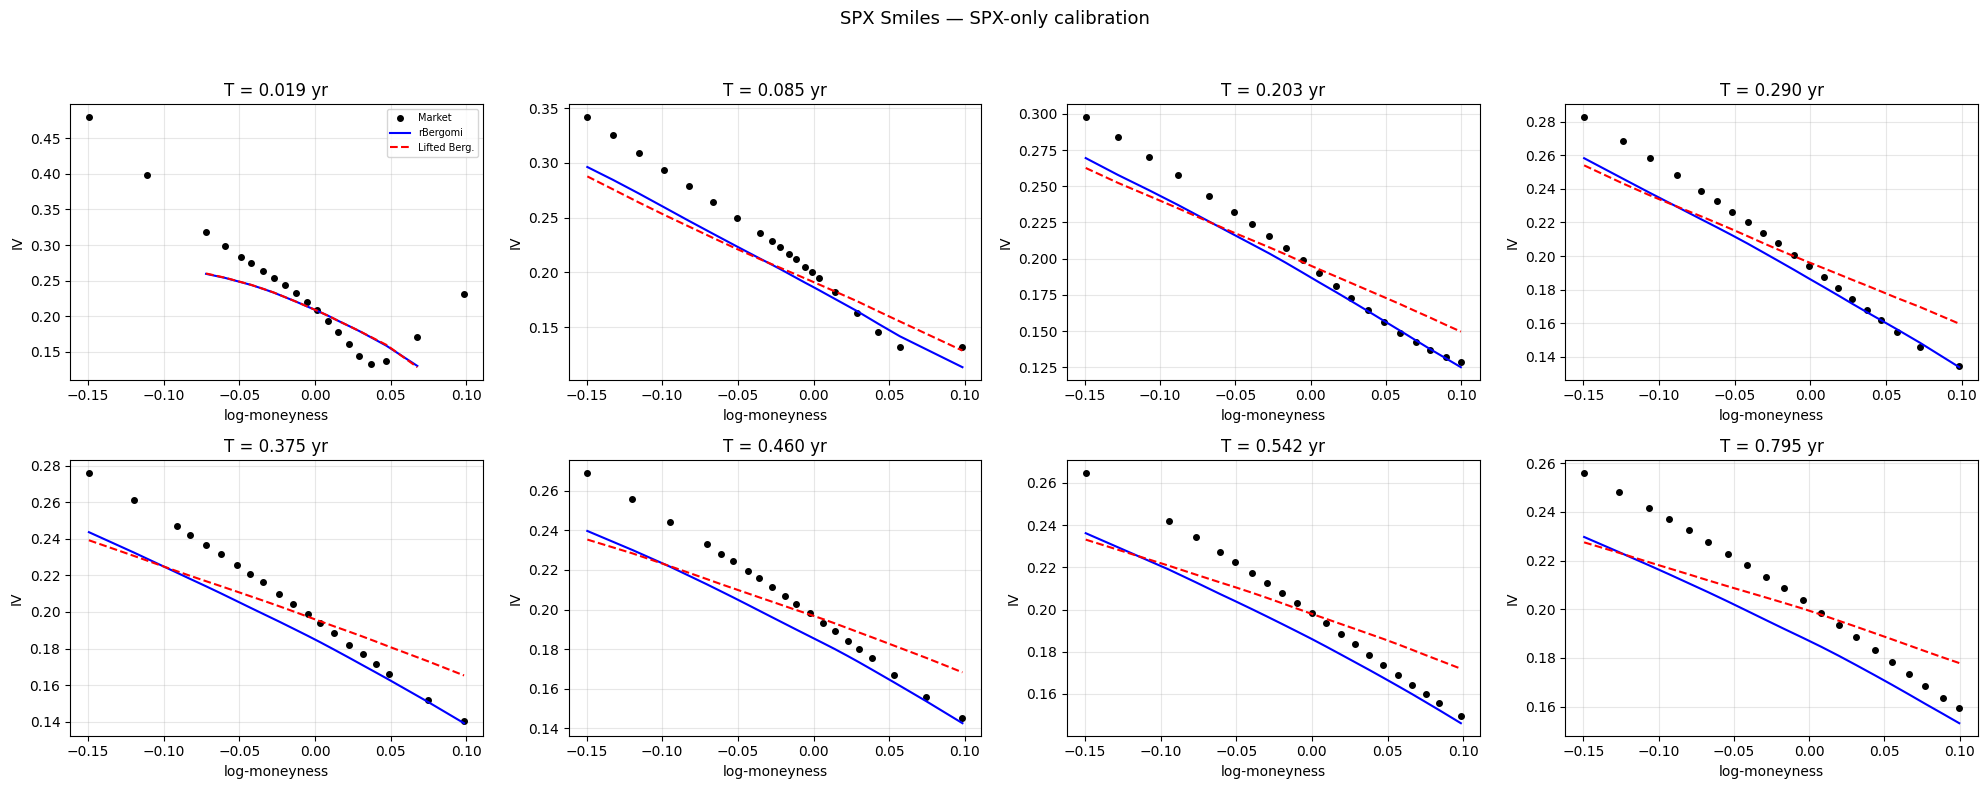


═══ MSE — SPX Smiles — SPX-only calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0192   0.000878      0.000886
 0.0849   0.000594      0.000772
 0.2027   0.000179      0.000355
 0.2904   0.000163      0.000266
 0.3753   0.000300      0.000313
 0.4603   0.000241      0.000241
 0.5425   0.000206      0.000217
 0.7945   0.000287      0.000222
  TOTAL   0.000356      0.000409


In [ ]:
print("\n── SPX-only calibration — SPX results ──")
compute_and_plot_spx(H_rb_spx, eta_rb_spx, rho_rb_spx,
                     H_lb_spx, eta_lb_spx, rho_lb_spx, 'SPX Smiles — SPX-only calibration')

In [ ]:
# Results: VIX smile plots + MSE
def compute_and_plot_vix(H_rb, eta_rb, rho_rb, H_lb, eta_lb, rho_lb, title_tag):
    """Simulate both models, plot VIX smiles per maturity, return MSE table."""
    _, _, tg_rb, dW_rb = rbergomi_simulate(
        H_rb, eta_rb, rho_rb, xi0_func, S0, r_val, T_MAX,
        N_STEPS_SHOW, N_PATHS_SHOW, seed=123)
    dt_rb = T_MAX / N_STEPS_SHOW

    c_, x_ = kernel_params(H_lb, N_FACTORS, R_GEOM)
    _, _, tg_lb, snaps_lb = lbergomi_simulate(
        c_, x_, eta_lb, H_lb, rho_lb, xi0_func, S0, r_val, T_MAX,
        N_STEPS_SHOW, N_PATHS_SHOW, snapshot_times=VIX_MATS, seed=123)

    n_vm = len(VIX_MATS)
    nc = min(4, n_vm); nr = int(np.ceil(n_vm / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(5 * nc, 4 * nr))
    axes = np.array(axes).flatten()
    mse_rows = []

    for j, Tv in enumerate(VIX_MATS):
        ax = axes[j]
        sub = vix_cal[vix_cal['expiration'] == Tv]
        if len(sub) == 0: continue
        fut = sub['future'].iloc[0]
        stk = sub['strike'].values
        iv_mkt = sub['implied_vol'].values

        vix_rb = rbergomi_vix(H_rb, eta_rb, xi0_func, dW_rb, dt_rb, Tv)
        iv_rb = mc_vix_ivs(vix_rb, fut, r_val, Tv, stk)

        if Tv in snaps_lb:
            vix_lb = lbergomi_vix(c_, x_, eta_lb, H_lb, xi0_func,
                                   snaps_lb[Tv], Tv)
        else:
            vix_lb = np.full(N_PATHS_SHOW, fut)
        iv_lb = mc_vix_ivs(vix_lb, fut, r_val, Tv, stk)

        ax.plot(stk, iv_mkt, 'ko', ms=4, label='Market')
        ok_rb, ok_lb = ~np.isnan(iv_rb), ~np.isnan(iv_lb)
        ax.plot(stk[ok_rb], iv_rb[ok_rb], 'b-', lw=1.5, label='rBergomi')
        ax.plot(stk[ok_lb], iv_lb[ok_lb], 'r--', lw=1.5, label='Lifted Berg.')
        ax.set_title(f'VIX T = {Tv:.3f} yr'); ax.set_xlabel('Strike')
        ax.set_ylabel('IV'); ax.grid(True, alpha=0.3)
        if j == 0: ax.legend(fontsize=7)
        mse_rows.append({'T': round(Tv, 4),
                         'MSE_rBerg': np.nanmean((iv_rb - iv_mkt)**2),
                         'MSE_LiftBerg': np.nanmean((iv_lb - iv_mkt)**2)})

    for k in range(j + 1, len(axes)): axes[k].set_visible(False)
    plt.suptitle(f'{title_tag}', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(save_path, f"{title_tag}.png"))
    plt.show()

    df = pd.DataFrame(mse_rows)
    df.loc[len(df)] = ['TOTAL', df['MSE_rBerg'].mean(), df['MSE_LiftBerg'].mean()]
    print(f"\n═══ MSE — {title_tag} ═══")
    print(df.to_string(index=False))


── SPX-only calibration — VIX results ──


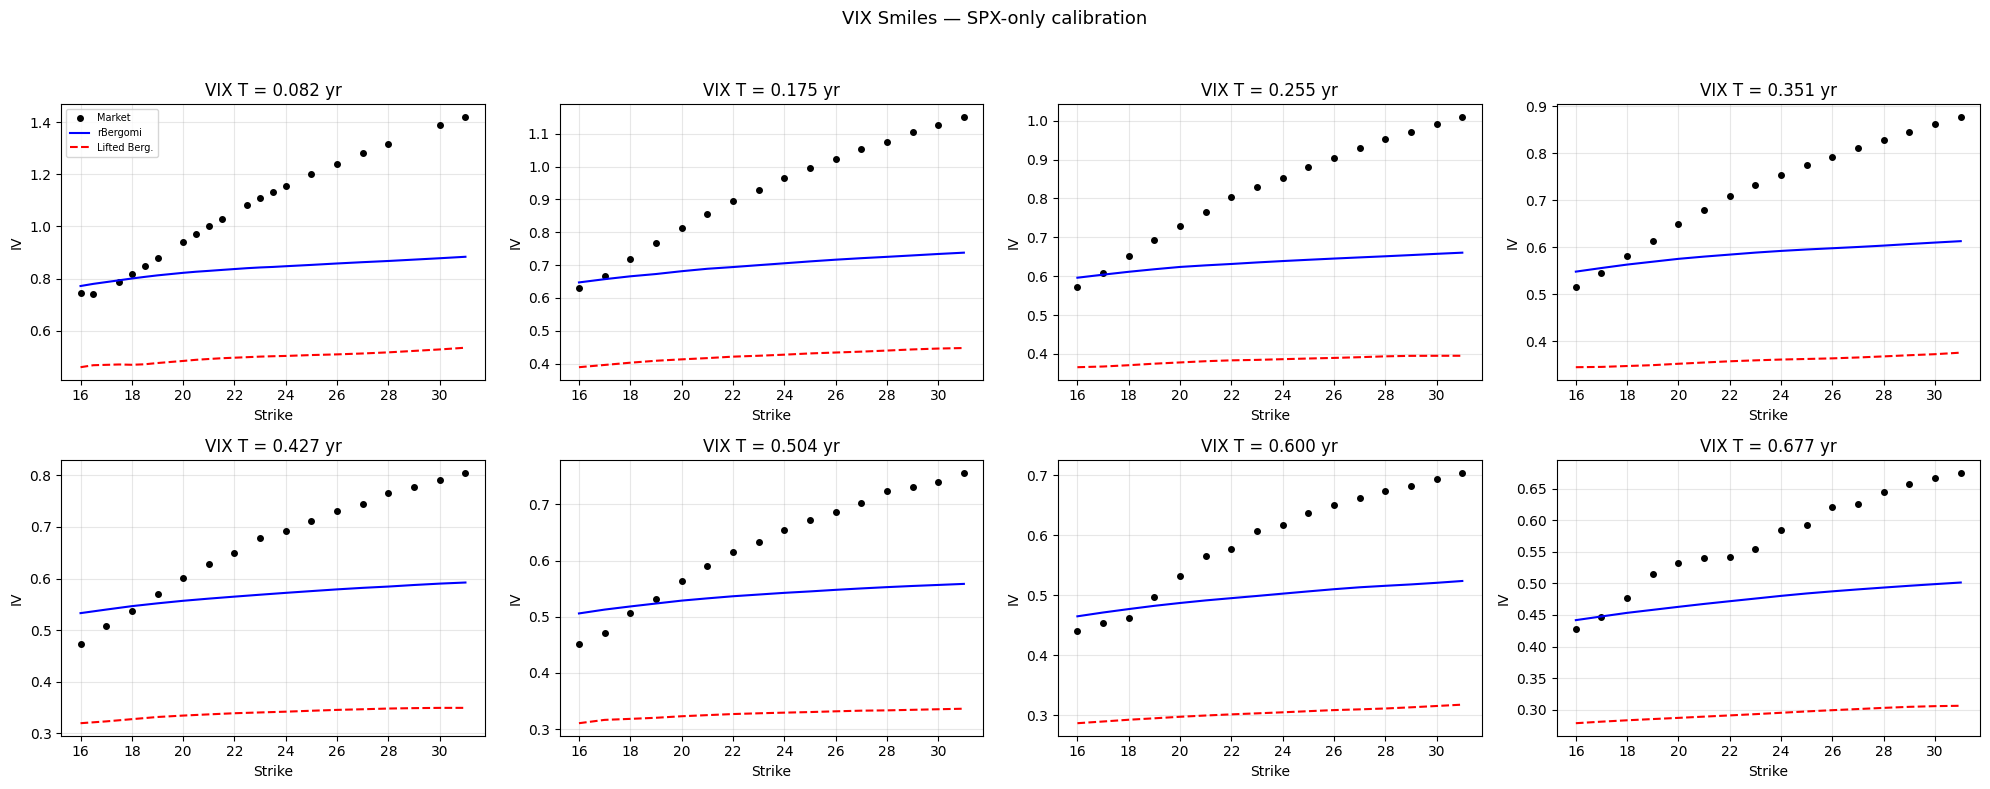


═══ MSE — VIX Smiles — SPX-only calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0822   0.080578      0.348385
 0.1753   0.068224      0.270417
 0.2548   0.048682      0.207250
 0.3507   0.027264      0.143143
 0.4274   0.016704      0.115524
 0.5041   0.014286      0.097714
    0.6   0.013374      0.088927
 0.6767   0.011995      0.080371
  TOTAL   0.035138      0.168966


In [ ]:
print("\n── SPX-only calibration — VIX results ──")
compute_and_plot_vix(H_rb_spx, eta_rb_spx, rho_rb_spx,
                     H_lb_spx, eta_lb_spx, rho_lb_spx, 'VIX Smiles — SPX-only calibration')

### 3.2. VIX-only calibration

In [ ]:
def _rberg_vix_obj(params):
    eta = params[0]
    _, _, tg, dW = _rberg_simulate(H_fixed, eta, rho_fixed)
    dt = T_MAX / int(T_MAX * N_STEPS_PER_YEAR)
    vd = _rberg_vix_dict(H_fixed, eta, dW, dt)
    return _vix_loss(vd, vix_cal)

def _lberg_vix_obj(params):
    eta = params[0]
    try:
        _, _, tg, snaps = _lberg_simulate(H_fixed, eta, rho_fixed)
        vd = _lberg_vix_dict(H_fixed, eta, snaps)
        return _vix_loss(vd, vix_cal)
    except Exception:
        return 1e6

H_rb_vix, eta_rb_vix, rho_rb_vix = calibrate_bergomi(_rberg_vix_obj, 'rBergomi [VIX only]')
H_lb_vix, eta_lb_vix, rho_lb_vix = calibrate_bergomi(_lberg_vix_obj, 'Lifted Bergomi [VIX only]')


Calibrating rBergomi [VIX only] (H=0.0610 fixed, rho=-0.9 fixed) …
  rBergomi [VIX only]: H=0.0610 (fixed), η=2.8681, ρ=-0.9 (fixed), loss=9.533285e-03
Calibrating Lifted Bergomi [VIX only] (H=0.0610 fixed, rho=-0.9 fixed) …
  Lifted Bergomi [VIX only]: H=0.0610 (fixed), η=3.5686, ρ=-0.9 (fixed), loss=9.045167e-03



── VIX-only calibration — SPX results ──


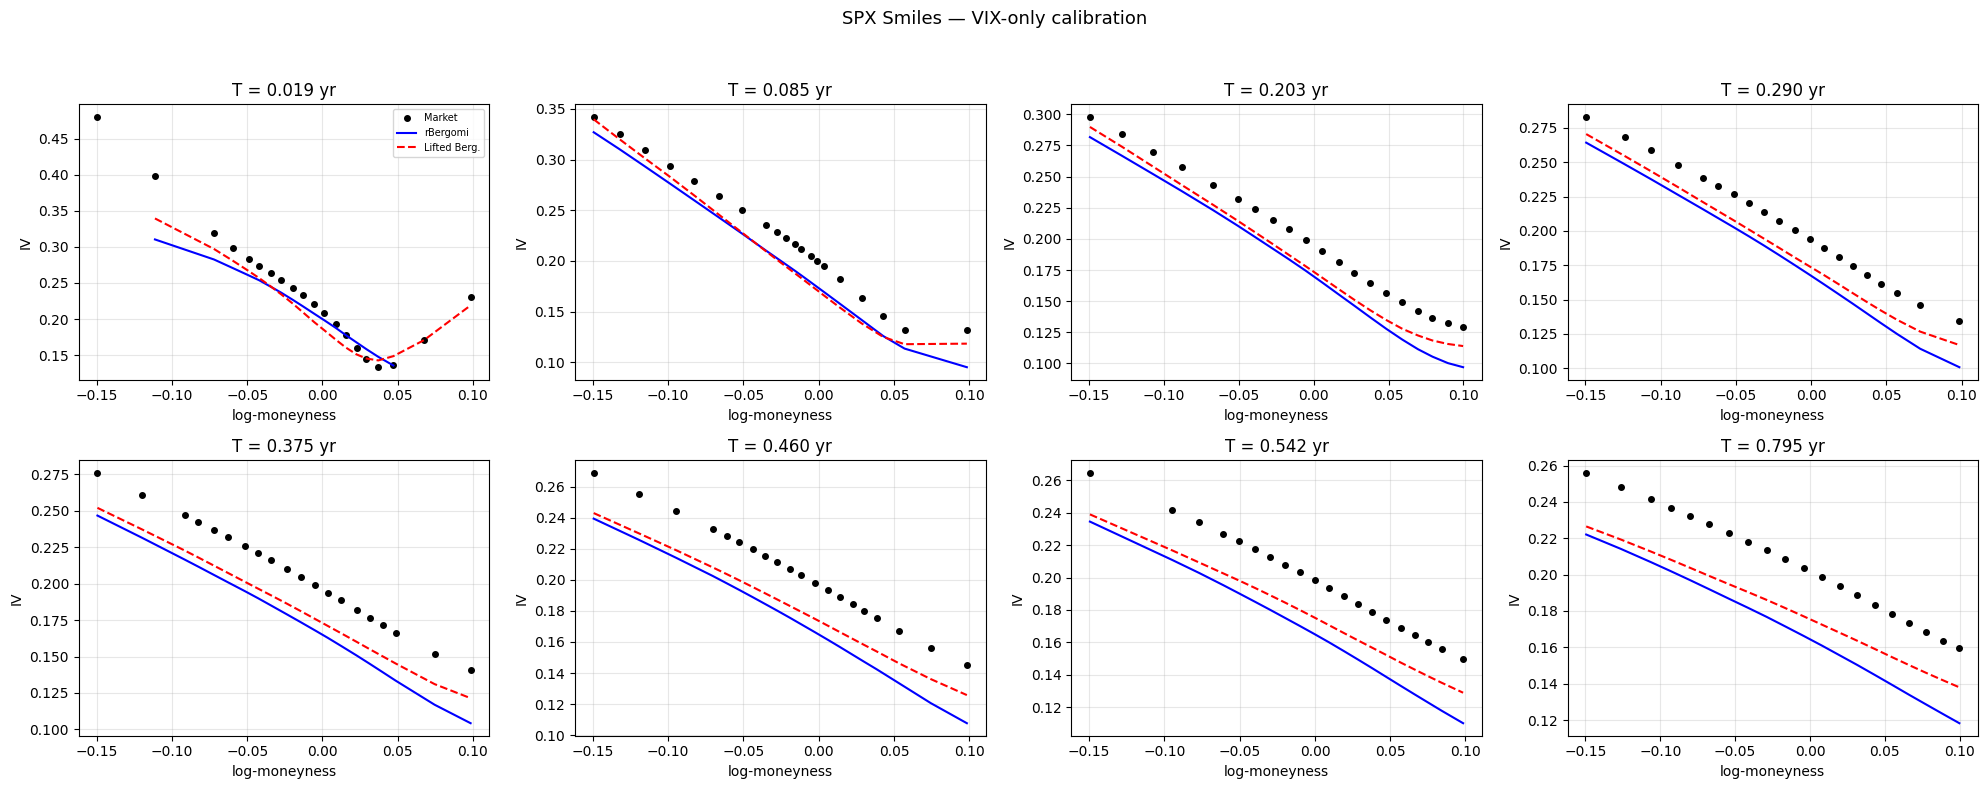


═══ MSE — SPX Smiles — VIX-only calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0192   0.000754      0.000481
 0.0849   0.000540      0.000491
 0.2027   0.000642      0.000336
 0.2904   0.000668      0.000343
 0.3753   0.000992      0.000531
 0.4603   0.001024      0.000546
 0.5425   0.001161      0.000529
 0.7945   0.001394      0.000692
  TOTAL   0.000897      0.000494


In [ ]:
# Results: SPX smile plots + MSE
print("\n── VIX-only calibration — SPX results ──")
compute_and_plot_spx(H_rb_vix, eta_rb_vix, rho_rb_vix,
                     H_lb_vix, eta_lb_vix, rho_lb_vix, 'SPX Smiles — VIX-only calibration')


── VIX-only calibration — VIX results ──


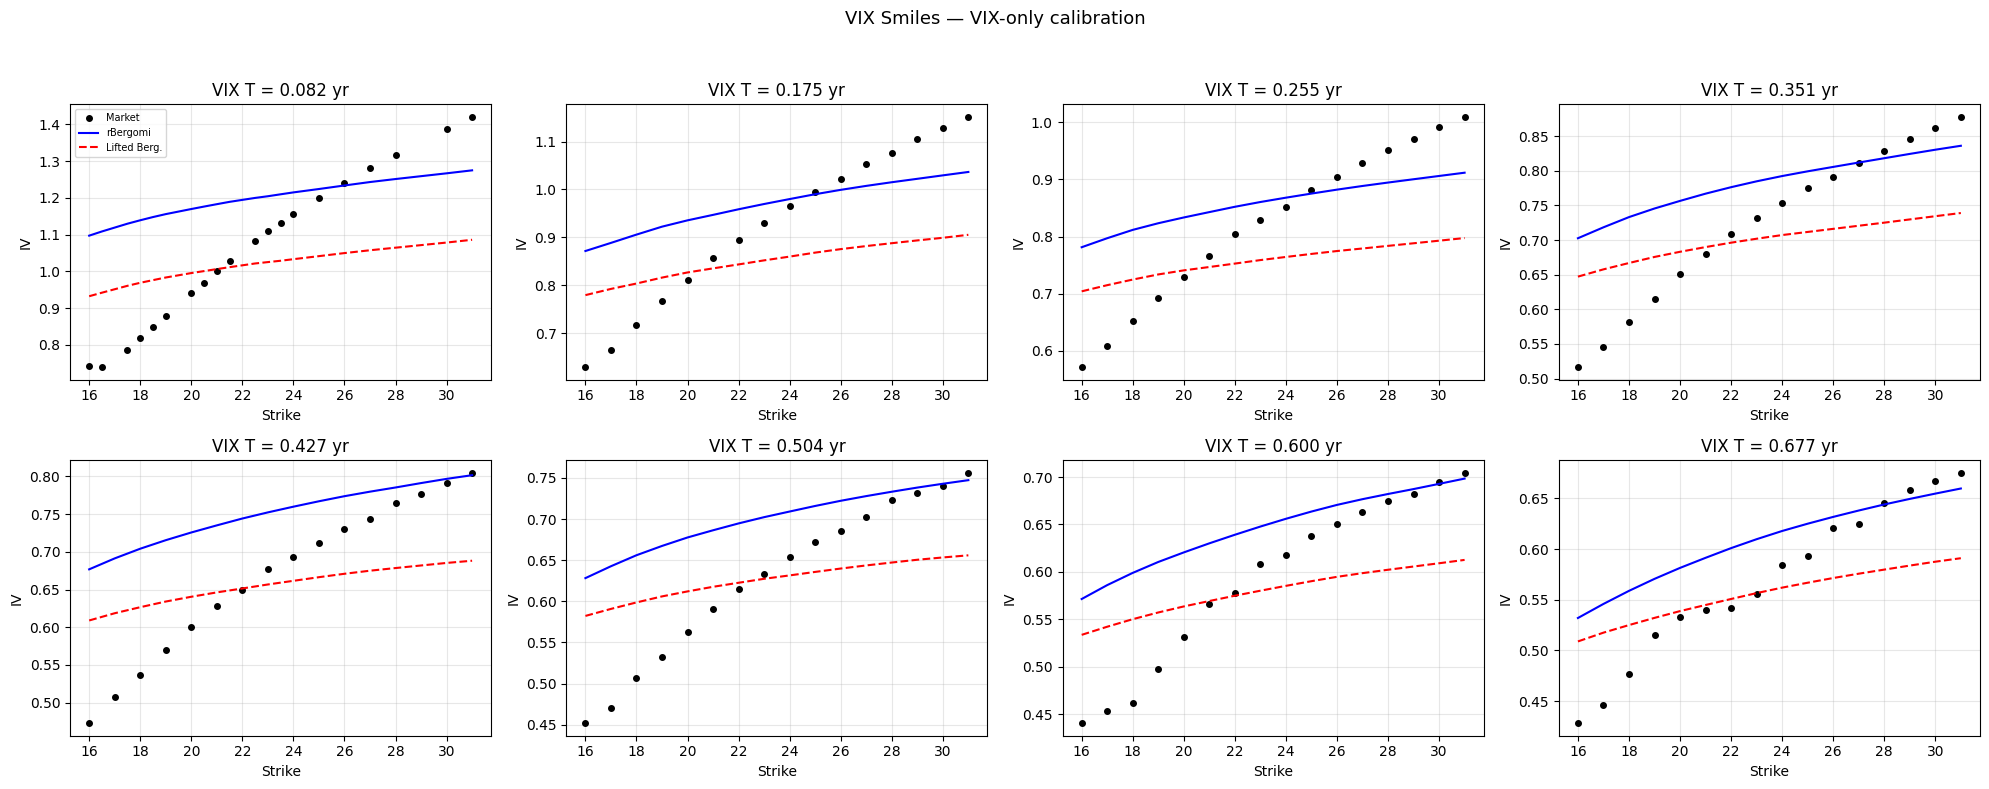


═══ MSE — VIX Smiles — VIX-only calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0822   0.043806      0.029032
 0.1753   0.014564      0.020481
 0.2548   0.010606      0.015628
 0.3507   0.008524      0.007658
 0.4274   0.011089      0.006142
 0.5041   0.008894      0.005398
    0.6   0.005392      0.004176
 0.6767   0.002810      0.002739
  TOTAL   0.013211      0.011407


In [ ]:
# Results: VIX smile plots + MSE
print("\n── VIX-only calibration — VIX results ──")
compute_and_plot_vix(H_rb_vix, eta_rb_vix, rho_rb_vix,
                     H_lb_vix, eta_lb_vix, rho_lb_vix, 'VIX Smiles — VIX-only calibration')

### 3.3. Joint calibration

In [ ]:
W_VIX = 1.0

def _rberg_joint_obj(params):
    eta = params[0]
    log_S, V, tg, dW = _rberg_simulate(H_fixed, eta, rho_fixed)
    dt = T_MAX / int(T_MAX * N_STEPS_PER_YEAR)
    vd = _rberg_vix_dict(H_fixed, eta, dW, dt)
    return _spx_loss(log_S, tg, spx_cal) + W_VIX * _vix_loss(vd, vix_cal)

def _lberg_joint_obj(params):
    eta = params[0]
    try:
        log_S, V, tg, snaps = _lberg_simulate(H_fixed, eta, rho_fixed)
        vd = _lberg_vix_dict(H_fixed, eta, snaps)
        return _spx_loss(log_S, tg, spx_cal) + W_VIX * _vix_loss(vd, vix_cal)
    except Exception:
        return 1e6

H_rb_j, eta_rb_j, rho_rb_j = calibrate_bergomi(_rberg_joint_obj, 'rBergomi [Joint]')
H_lb_j, eta_lb_j, rho_lb_j = calibrate_bergomi(_lberg_joint_obj, 'Lifted Bergomi [Joint]')

Calibrating rBergomi [Joint] (H=0.0610 fixed, rho=-0.9 fixed) …
  rBergomi [Joint]: H=0.0610 (fixed), η=2.8512, ρ=-0.9 (fixed), loss=1.033358e-02
Calibrating Lifted Bergomi [Joint] (H=0.0610 fixed, rho=-0.9 fixed) …
  Lifted Bergomi [Joint]: H=0.0610 (fixed), η=3.5431, ρ=-0.9 (fixed), loss=1.141921e-02



── Joint calibration — SPX results ──


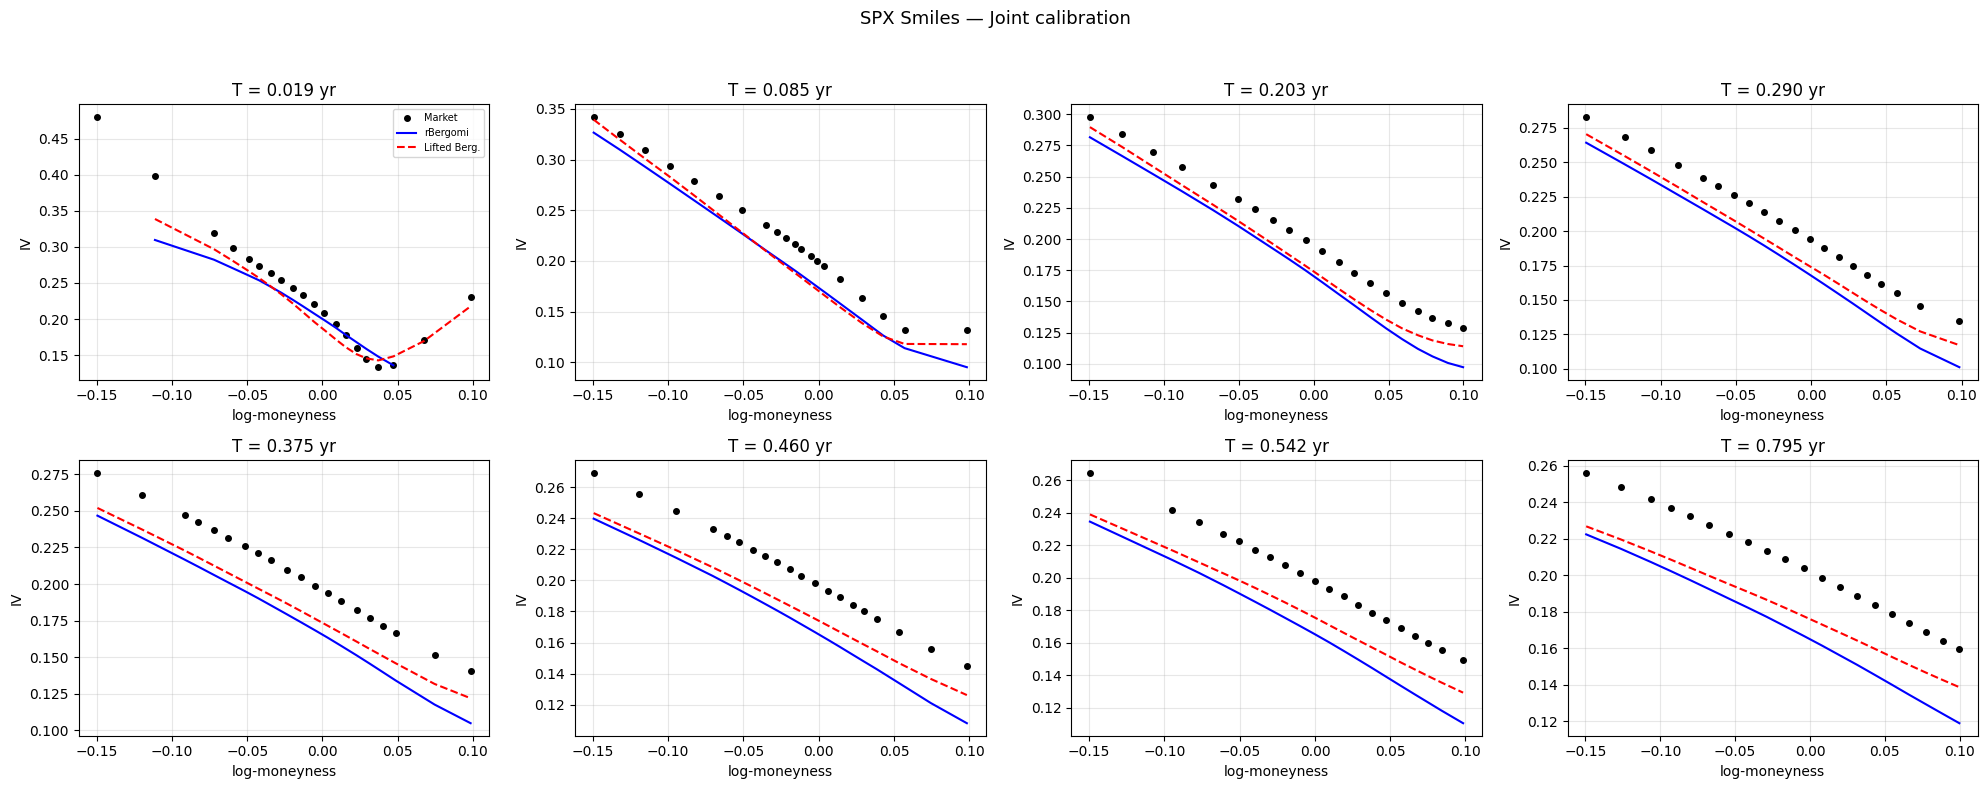


═══ MSE — SPX Smiles — Joint calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0192   0.000765      0.000483
 0.0849   0.000535      0.000483
 0.2027   0.000628      0.000325
 0.2904   0.000652      0.000331
 0.3753   0.000972      0.000517
 0.4603   0.001002      0.000530
 0.5425   0.001134      0.000511
 0.7945   0.001363      0.000673
  TOTAL   0.000881      0.000482


In [ ]:
# Results SPX
print("\n── Joint calibration — SPX results ──")
compute_and_plot_spx(H_rb_j, eta_rb_j, rho_rb_j,
                     H_lb_j, eta_lb_j, rho_lb_j, 'SPX Smiles — Joint calibration')


── Joint calibration — VIX results ──


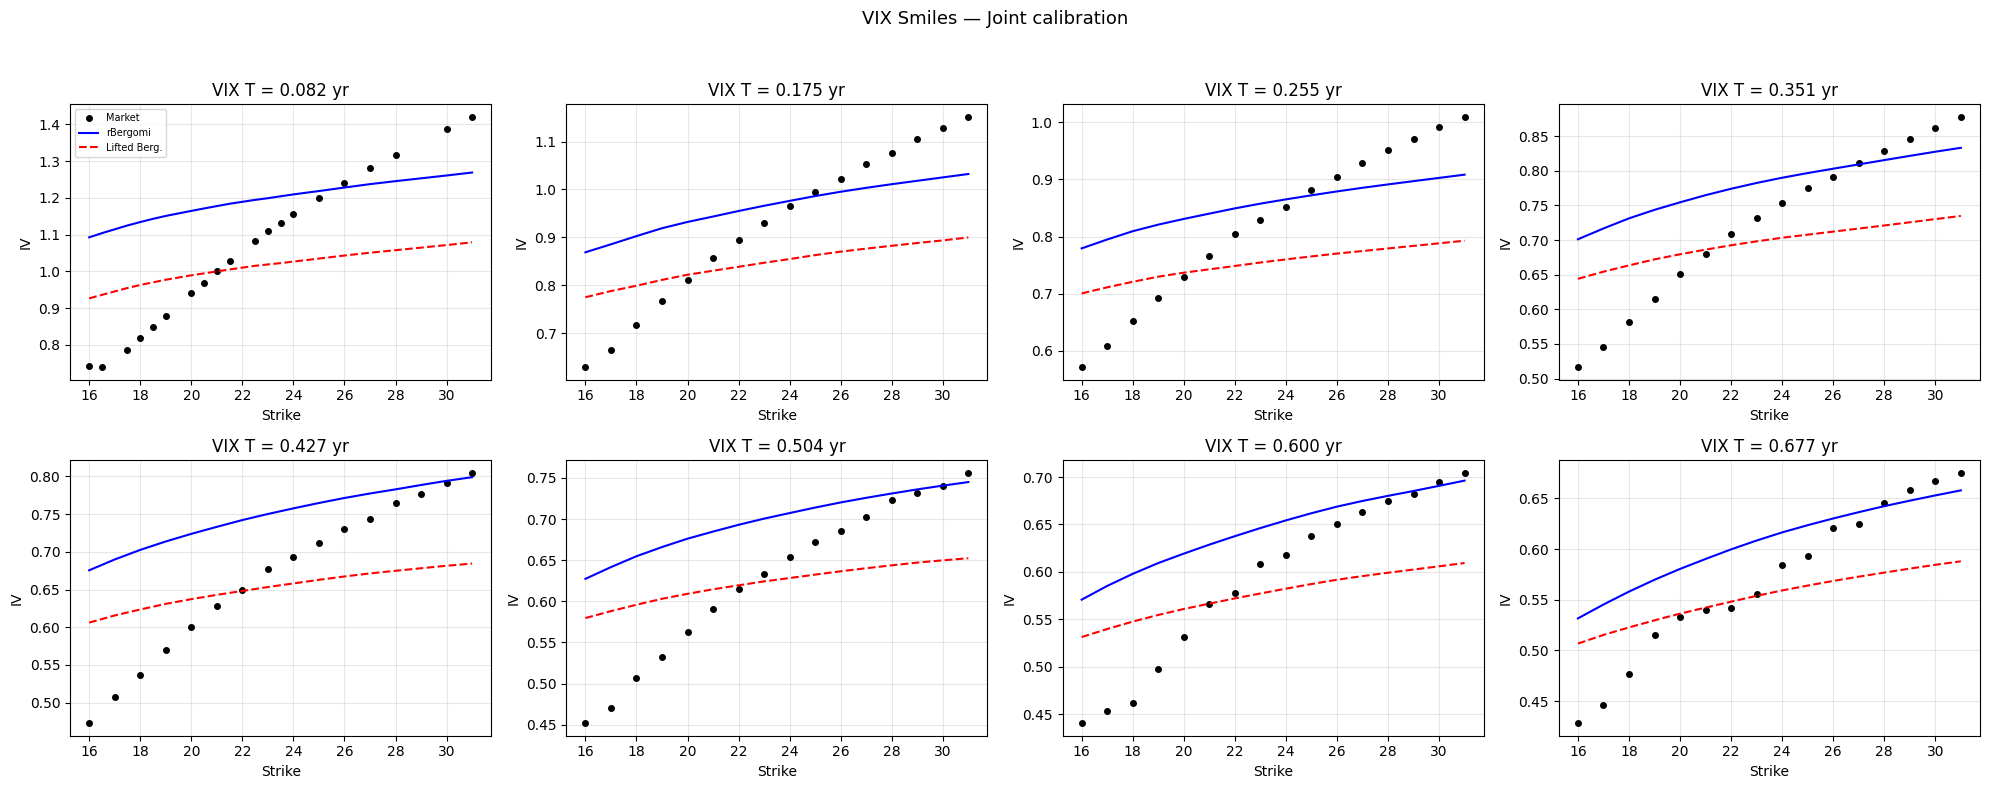


═══ MSE — VIX Smiles — Joint calibration ═══
      T  MSE_rBerg  MSE_LiftBerg
 0.0822   0.042517      0.029699
 0.1753   0.014355      0.021312
 0.2548   0.010488      0.016251
 0.3507   0.008320      0.007901
 0.4274   0.010797      0.006269
 0.5041   0.008695      0.005455
    0.6   0.005269      0.004289
 0.6767   0.002746      0.002847
  TOTAL   0.012898      0.011753


In [ ]:
# Results VIX
print("\n── Joint calibration — VIX results ──")
compute_and_plot_vix(H_rb_j, eta_rb_j, rho_rb_j,
                     H_lb_j, eta_lb_j, rho_lb_j, 'VIX Smiles — Joint calibration')

In [ ]:
# Summary of all calibrations
print("\n═══ Calibrated parameters summary ═══")
print(f"{'':20s}  {'H':>6}  {'η':>6}  {'ρ':>6}")
print(f"{'rBerg [SPX]':20s}  {H_rb_spx:6.4f}  {eta_rb_spx:6.4f}  {rho_rb_spx:6.4f}")
print(f"{'rBerg [VIX]':20s}  {H_rb_vix:6.4f}  {eta_rb_vix:6.4f}  {rho_rb_vix:6.4f}")
print(f"{'rBerg [Joint]':20s}  {H_rb_j:6.4f}  {eta_rb_j:6.4f}  {rho_rb_j:6.4f}")
print(f"{'LiftBerg [SPX]':20s}  {H_lb_spx:6.4f}  {eta_lb_spx:6.4f}  {rho_lb_spx:6.4f}")
print(f"{'LiftBerg [VIX]':20s}  {H_lb_vix:6.4f}  {eta_lb_vix:6.4f}  {rho_lb_vix:6.4f}")
print(f"{'LiftBerg [Joint]':20s}  {H_lb_j:6.4f}  {eta_lb_j:6.4f}  {rho_lb_j:6.4f}")


═══ Calibrated parameters summary ═══
                           H       η       ρ
rBerg [SPX]           0.0610  1.8683  -0.9000
rBerg [VIX]           0.0610  2.8681  -0.9000
rBerg [Joint]         0.0610  2.8512  -0.9000
LiftBerg [SPX]        0.0610  1.6610  -0.9000
LiftBerg [VIX]        0.0610  3.5686  -0.9000
LiftBerg [Joint]      0.0610  3.5431  -0.9000


### 3.4. Manual parameters explorer

H = 0.061,  η = 3,  ρ = -0.8,  ρη = -2.4000
paths = 5000,  steps = 205



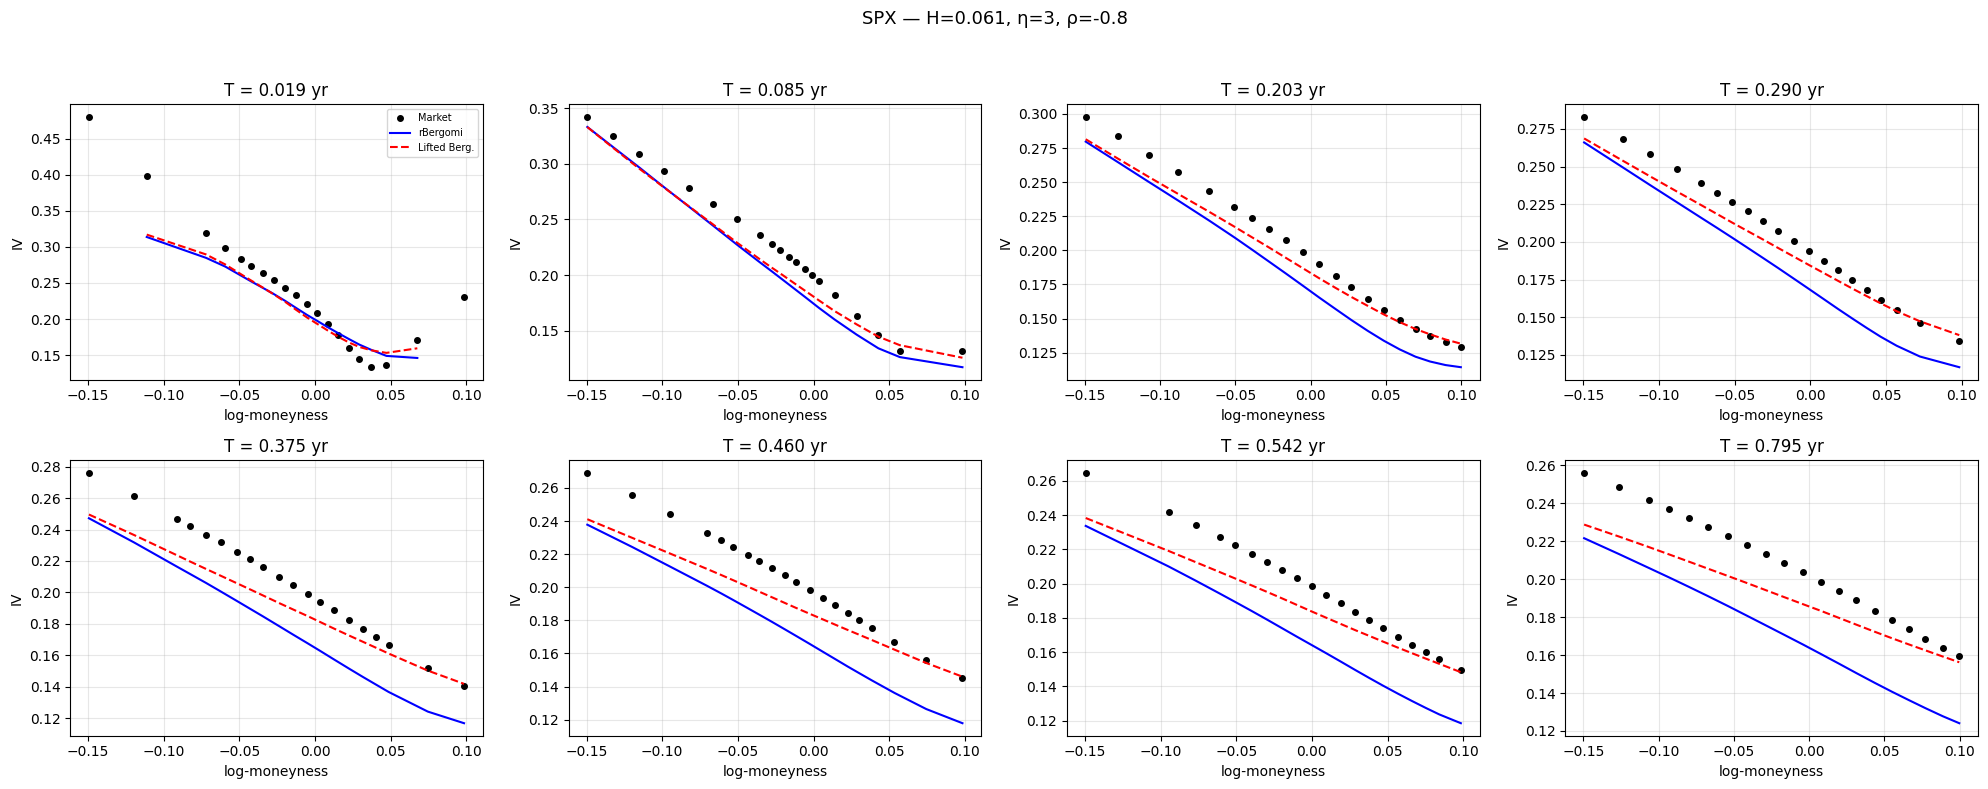

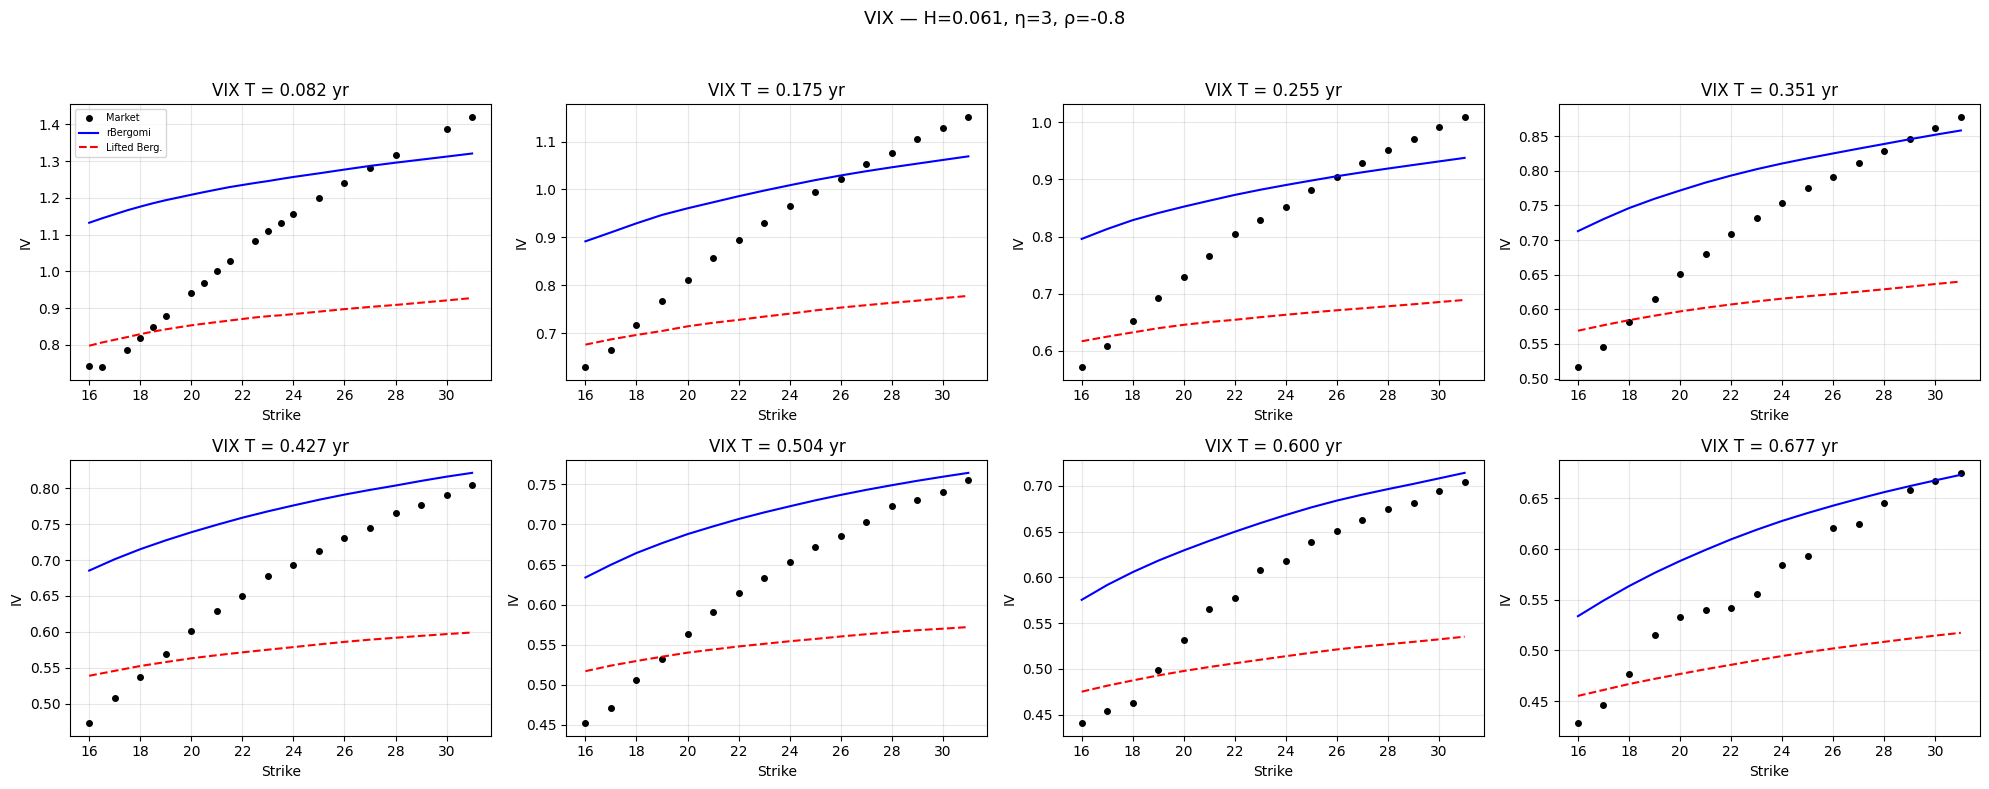

═══ SPX MSE ═══
      T   MSE_rB   MSE_LB
 0.0192 0.000766 0.000694
 0.0849 0.000393 0.000263
 0.2027 0.000471 0.000126
 0.2904 0.000541 0.000115
 0.3753 0.000917 0.000282
 0.4603 0.001006 0.000283
 0.5425 0.001097 0.000227
 0.7945 0.001361 0.000319
  TOTAL 0.000819 0.000289

═══ VIX MSE ═══
      T   MSE_rB   MSE_LB
 0.0822 0.055512 0.064632
 0.1753 0.016985 0.052827
 0.2548 0.011964 0.039687
 0.3507 0.010332 0.021078
 0.4274 0.013454 0.015392
 0.5041 0.010473 0.012193
    0.6 0.006383 0.011484
 0.6767 0.003329 0.009441
  TOTAL 0.016054 0.028342


In [ ]:
# Choose the parameters here
H_manual   = 0.061
eta_manual = 3
rho_manual = -0.8

# MC settings
N_PATHS_MANUAL = 5000
N_STEPS_MANUAL = int(T_MAX * 252)

# Simulations
print(f"H = {H_manual},  η = {eta_manual},  ρ = {rho_manual},  ρη = {rho_manual*eta_manual:.4f}")
print(f"paths = {N_PATHS_MANUAL},  steps = {N_STEPS_MANUAL}\n")

log_S_rb, V_rb, tg_rb, dW_rb = rbergomi_simulate(
    H_manual, eta_manual, rho_manual, xi0_func, S0, r_val,
    T_MAX, N_STEPS_MANUAL, N_PATHS_MANUAL, seed=123)
dt_rb = T_MAX / N_STEPS_MANUAL

c_m, x_m = kernel_params(H_manual, N_FACTORS, R_GEOM)
log_S_lb, V_lb, tg_lb, snaps_lb = lbergomi_simulate(
    c_m, x_m, eta_manual, H_manual, rho_manual, xi0_func, S0, r_val,
    T_MAX, N_STEPS_MANUAL, N_PATHS_MANUAL,
    snapshot_times=VIX_MATS, seed=123)

# SPX smiles
pr_rb = lambda K, T: mc_spx_calls(log_S_rb, tg_rb, r_val, K, T)
pr_lb = lambda K, T: mc_spx_calls(log_S_lb, tg_lb, r_val, K, T)
iv_rb = spx_model_ivs(pr_rb, spx_cal, S0, r_val)
iv_lb = spx_model_ivs(pr_lb, spx_cal, S0, r_val)

mats = sorted(spx_cal['expiration'].unique())
nc = min(4, len(mats)); nr = int(np.ceil(len(mats) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = np.array(axes).flatten()
mse_spx = []

for j, T_val in enumerate(mats):
    ax = axes[j]
    mask = spx_cal['expiration'] == T_val
    lm = spx_cal.loc[mask, 'log_moneyness'].values
    iv_m = spx_cal.loc[mask, 'implied_vol'].values
    rb = iv_rb[mask.values]; lb = iv_lb[mask.values]
    ax.plot(lm, iv_m, 'ko', ms=4, label='Market')
    ok_rb = ~np.isnan(rb); ok_lb = ~np.isnan(lb)
    ax.plot(lm[ok_rb], rb[ok_rb], 'b-', lw=1.5, label='rBergomi')
    ax.plot(lm[ok_lb], lb[ok_lb], 'r--', lw=1.5, label='Lifted Berg.')
    ax.set_title(f'T = {T_val:.3f} yr'); ax.set_xlabel('log-moneyness')
    ax.set_ylabel('IV'); ax.grid(True, alpha=0.3)
    if j == 0: ax.legend(fontsize=7)
    mse_spx.append({'T': round(T_val,4),
                     'MSE_rB': np.nanmean((rb-iv_m)**2),
                     'MSE_LB': np.nanmean((lb-iv_m)**2)})
for k in range(j+1, len(axes)): axes[k].set_visible(False)
plt.suptitle(f'SPX — H={H_manual}, η={eta_manual}, ρ={rho_manual}', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

# VIX smiles
nc = min(4, len(VIX_MATS)); nr = int(np.ceil(len(VIX_MATS) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = np.array(axes).flatten()
mse_vix = []

for j, Tv in enumerate(VIX_MATS):
    ax = axes[j]
    sub = vix_cal[vix_cal['expiration'] == Tv]
    if len(sub) == 0: continue
    fut = sub['future'].iloc[0]
    stk = sub['strike'].values
    iv_m = sub['implied_vol'].values

    vix_rb = rbergomi_vix(H_manual, eta_manual, xi0_func, dW_rb, dt_rb, Tv)
    iv_rb_v = mc_vix_ivs(vix_rb, fut, r_val, Tv, stk)

    if Tv in snaps_lb:
        vix_lb = lbergomi_vix(c_m, x_m, eta_manual, H_manual,
                               xi0_func, snaps_lb[Tv], Tv)
    else:
        vix_lb = np.full(N_PATHS_MANUAL, fut)
    iv_lb_v = mc_vix_ivs(vix_lb, fut, r_val, Tv, stk)

    ax.plot(stk, iv_m, 'ko', ms=4, label='Market')
    ok_rb = ~np.isnan(iv_rb_v); ok_lb = ~np.isnan(iv_lb_v)
    ax.plot(stk[ok_rb], iv_rb_v[ok_rb], 'b-', lw=1.5, label='rBergomi')
    ax.plot(stk[ok_lb], iv_lb_v[ok_lb], 'r--', lw=1.5, label='Lifted Berg.')
    ax.set_title(f'VIX T = {Tv:.3f} yr'); ax.set_xlabel('Strike')
    ax.set_ylabel('IV'); ax.grid(True, alpha=0.3)
    if j == 0: ax.legend(fontsize=7)
    mse_vix.append({'T': round(Tv,4),
                     'MSE_rB': np.nanmean((iv_rb_v-iv_m)**2),
                     'MSE_LB': np.nanmean((iv_lb_v-iv_m)**2)})
for k in range(j+1, len(axes)): axes[k].set_visible(False)
plt.suptitle(f'VIX — H={H_manual}, η={eta_manual}, ρ={rho_manual}', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

# Summary table
df_s = pd.DataFrame(mse_spx); df_v = pd.DataFrame(mse_vix)
df_s.loc[len(df_s)] = ['TOTAL', df_s['MSE_rB'].mean(), df_s['MSE_LB'].mean()]
df_v.loc[len(df_v)] = ['TOTAL', df_v['MSE_rB'].mean(), df_v['MSE_LB'].mean()]
print("═══ SPX MSE ═══"); print(df_s.to_string(index=False))
print("\n═══ VIX MSE ═══"); print(df_v.to_string(index=False))

## 4. Regularity study

In [ ]:
def regularity_study(log_var, dt, q_values=(0.5, 1.0, 1.5, 2.0, 3.0),
                     max_lag=100, name='Model'):
    """
    Estimate the Hurst exponent from log-variance paths.
    """
    N_paths, N_total = log_var.shape
    lags = np.arange(1, min(max_lag + 1, N_total // 2))

    # m(q, Δ) scaling
    zeta = {}
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    for q in q_values:
        m_q = np.array([np.mean(np.abs(log_var[:, lag:] - log_var[:, :-lag])**q)
                        for lag in lags])
        ll, lm = np.log(lags.astype(float)), np.log(np.maximum(m_q, 1e-30))
        sl, ic = np.polyfit(ll, lm, 1)
        zeta[q] = sl
        ax1.plot(ll, lm, '.', ms=3)
        ax1.plot(ll, sl * ll + ic, '-', lw=1.2, label=f'q={q:.1f}, ζ={sl:.3f}')
    ax1.set_xlabel('log(Δ)'); ax1.set_ylabel('log(m(q,Δ))')
    ax1.set_title(f'Scaling of m(q,Δ) — {name}')
    ax1.legend(); ax1.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"Scaling_{name}.png"))
    plt.show()

    # Monofractality: ζ_q vs q
    qs = np.array(list(zeta.keys()))
    zs = np.array(list(zeta.values()))
    H_fit, _ = np.polyfit(qs, zs, 1)

    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.plot(qs, zs, 'bo', ms=6, label=r'$\zeta_q$')
    ax2.plot(qs, H_fit * qs, 'r-', lw=1.5, label=f'Linear fit: H ≈ {H_fit:.4f}')
    ax2.set_xlabel('q'); ax2.set_ylabel(r'$\zeta_q$')
    ax2.set_title(f'Monofractality — {name}')
    ax2.legend(); ax2.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"Monofractality_{name}.png"))
    plt.show()

    print(f"{name}: estimated H from regularity = {H_fit:.4f}")
    return H_fit

In [ ]:
# Simulate variance paths for regularity
T_REG = 2.0
N_STEPS_REG = 1000
N_PATHS_REG = 200

# rBergomi variance
_, V_reg_rb, _, _ = rbergomi_simulate(
    H_rb_j, eta_rb_j, rho_rb_j, xi0_func, S0, r_val,
    T_REG, N_STEPS_REG, N_PATHS_REG, seed=77)

# Lifted Bergomi variance
c_reg, x_reg = kernel_params(H_lb_j, N_FACTORS, R_GEOM)
_, V_reg_lb, _, _ = lbergomi_simulate(
    c_reg, x_reg, eta_lb_j, H_lb_j, rho_lb_j, xi0_func, S0, r_val,
    T_REG, N_STEPS_REG, N_PATHS_REG, seed=77)

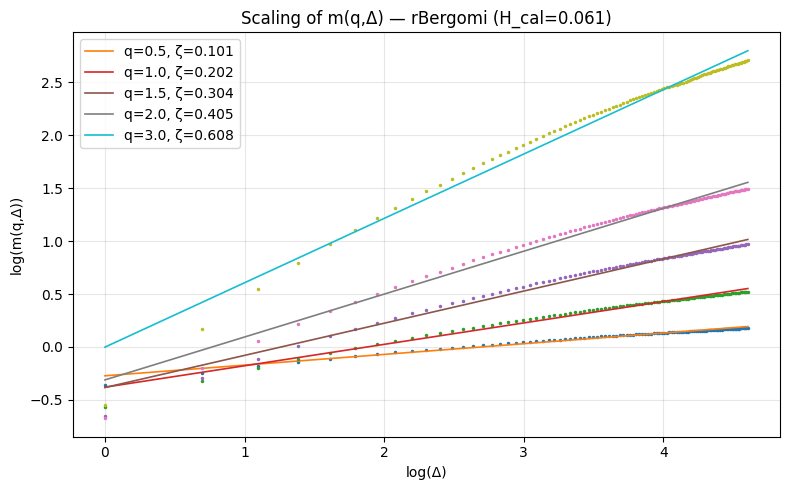

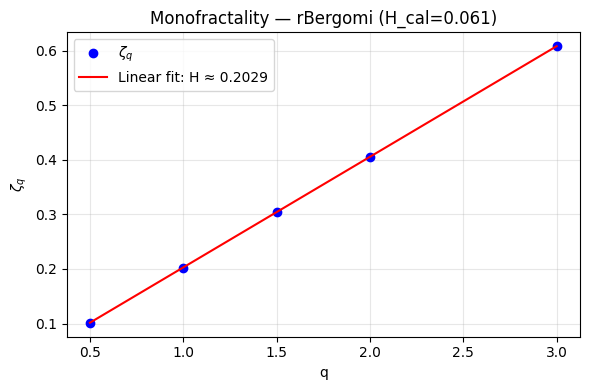

rBergomi (H_cal=0.061): estimated H from regularity = 0.2029


In [ ]:
# Regularity analysis
log_V_rb = np.log(np.maximum(V_reg_rb, 1e-20))
H_reg_rb = regularity_study(log_V_rb, T_REG / N_STEPS_REG,
                             name=f'rBergomi (H_cal={H_rb_j:.3f})')

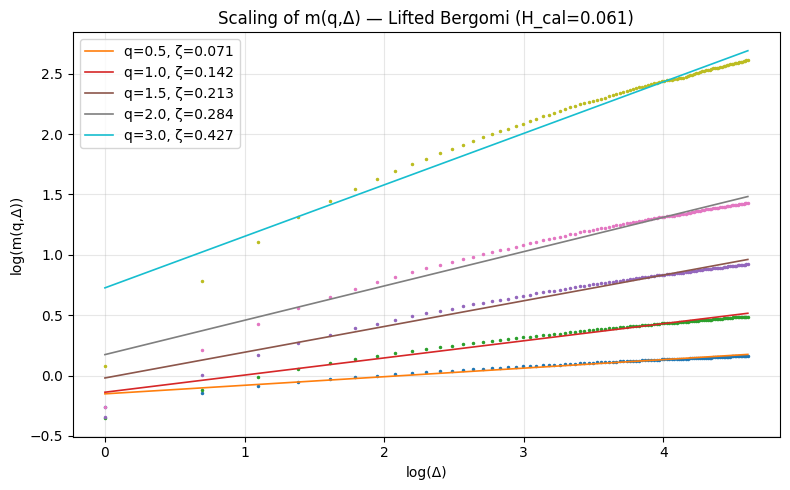

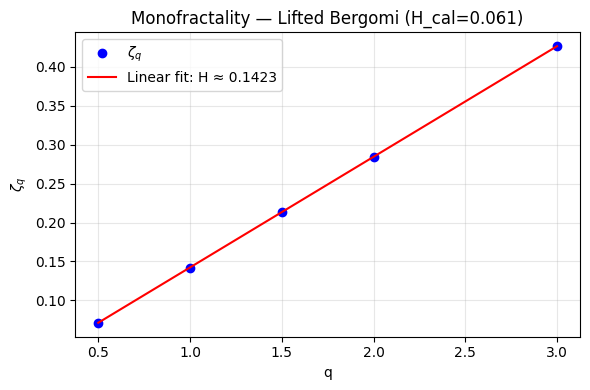

Lifted Bergomi (H_cal=0.061): estimated H from regularity = 0.1423


In [ ]:
log_V_lb = np.log(np.maximum(V_reg_lb, 1e-20))
H_reg_lb = regularity_study(log_V_lb, T_REG / N_STEPS_REG,
                             name=f'Lifted Bergomi (H_cal={H_lb_j:.3f})')

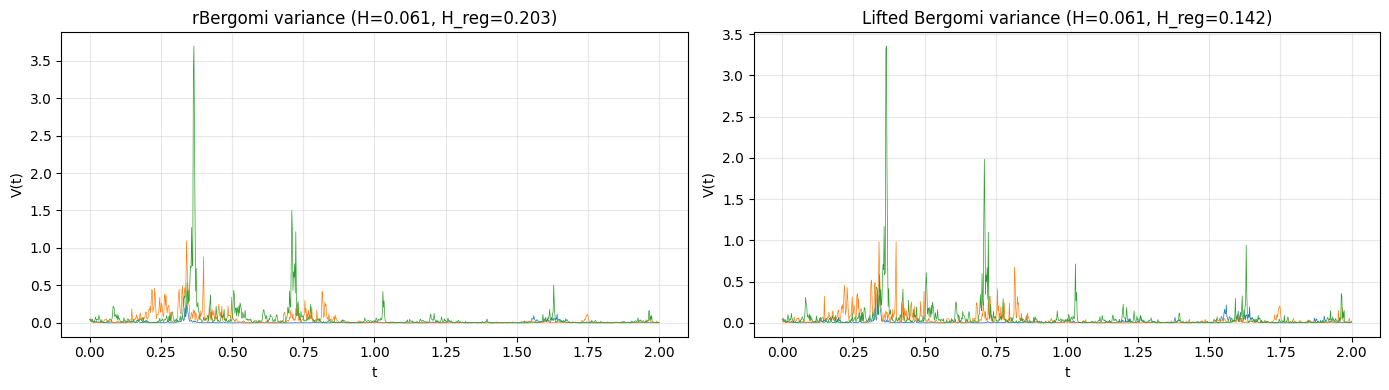

In [ ]:
# Sample paths comparison
t_reg = np.linspace(0, T_REG, N_STEPS_REG + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for p in range(3):
    ax1.plot(t_reg, V_reg_rb[p], lw=0.5)
    ax2.plot(t_reg, np.maximum(V_reg_lb[p], 0), lw=0.5)
ax1.set_title(f'rBergomi variance (H={H_rb_j:.3f}, H_reg={H_reg_rb:.3f})')
ax2.set_title(f'Lifted Bergomi variance (H={H_lb_j:.3f}, H_reg={H_reg_lb:.3f})')
for ax in (ax1, ax2):
    ax.set_xlabel('t'); ax.set_ylabel('V(t)'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "Samples.png"))
plt.show()

In [ ]:
print(f"\n═══ Regularity summary ═══")
print(f"  rBergomi:       H_calibrated = {H_rb_j:.4f},  H_regularity = {H_reg_rb:.4f}")
print(f"  Lifted Bergomi: H_calibrated = {H_lb_j:.4f},  H_regularity = {H_reg_lb:.4f}")


═══ Regularity summary ═══
  rBergomi:       H_calibrated = 0.0610,  H_regularity = 0.2029
  Lifted Bergomi: H_calibrated = 0.0610,  H_regularity = 0.1423
